# dvl_deeponet for A-KIT DVL + IMU to Cartesian Velocity

This notebook predicts **Cartesian DVL velocity** from a time history of:

```text
4 DVL beams at 1 Hz + IMU accel/gyro to DVL time
```

Expected files:

| File | Meaning |
|---|---|
| `A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy` | `(N,5)` = `[time, beam1, beam2, beam3, beam4]`, or `(N,4)` = beams only |
| `A-KIT/Data/Trajectory1/DVL_trajectory1.csv` | GT Cartesian DVL velocity columns |
| `A-KIT/AUV_IMU_npy/IMU_trajectory1.npy` | `(M,7)` = `[time, ax, ay, az, gx, gy, gz]` at about 100 Hz |

The pipeline is:

```text
DVL trajectory timestamps, 1 Hz
    -> load matching 100 Hz IMU trajectory
    -> interpolate IMU accel/gyro onto DVL timestamps
    -> concatenate [beam1..beam4, ax, ay, az, gx, gy, gz]
    -> windowed DVL+IMU history
    -> dvl_deeponet velocity prediction
    -> compare against classical least-squares DVL velocity
```

Important notes:

- This uses IMU as **additional neural-network input features**.
- It does not yet perform full strapdown INS mechanization.
- IMU format is assumed to be `[time, ax, ay, az, gx, gy, gz]`.


In [1]:
# ============================================================
# 0. Imports, setup, and reproducibility
# ============================================================

import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = torch.cuda.is_available()

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print("Using device:", DEVICE)

SAVE_DIR = Path("dvl_deeponet_dvl_imu_velocity_results")
FIG_DIR = SAVE_DIR / "figures"
CKPT_DIR = SAVE_DIR / "checkpoints"
DATA_DIR = SAVE_DIR / "arrays"
for directory in (FIG_DIR, CKPT_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Results folder:", SAVE_DIR.resolve())


Using device: cuda
Results folder: /home/asahoo/DVL/dvl_deeponet_dvl_imu_velocity_results


In [2]:
# ============================================================
# 1. Load A-KIT DVL beams, high-rate IMU, and Cartesian velocity GT
# ============================================================
# Expected per trajectory:
#   A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy
#   A-KIT/Data/Trajectory1/DVL_trajectory1.csv
#   A-KIT/AUV_IMU_npy/IMU_trajectory1.npy
#
# DVL_beams_traj_*.npy shape:
#   (N,5) = [time, beam1, beam2, beam3, beam4]
#   or (N,4) = [beam1, beam2, beam3, beam4]
#
# IMU_trajectory*.npy shape:
#   (M,7) = [time, ax, ay, az, gx, gy, gz]
#   usually 100 Hz, resampled here to DVL timestamps.
# ============================================================

import re
import pandas as pd

DATA_ROOT = Path("A-KIT/Data")
IMU_ROOT = Path("A-KIT/AUV_IMU_npy")
ALPHA_DEG = 20.0

TRAIN_TRAJECTORIES =[1, 6, 7, 8, 9, 10, 11, 12, 13]                 
VAL_TRAJECTORIES = [2,3] 
TEST_TRAJECTORIES = [4,5]

REQUIRED_VELOCITY_COLUMNS = ["DVL X [m/s]", "DVL Y [m/s]", "DVL Z [m/s]"]

# IMU_trajectory*.npy format is fixed by your data:
# [time, ax, ay, az, gx, gy, gz]
IMU_FEATURE_NAMES = ["ax", "ay", "az", "gx", "gy", "gz"]
IMU_RESAMPLE_MODE = "average"



def build_dvl_H(alpha_deg=20.0):
    """Build the 4x3 DVL beam geometry matrix used by the A-KIT beam generator."""
    alpha = np.deg2rad(alpha_deg)
    H = []
    for i in range(4):
        psi = np.deg2rad(45 + i * 90)
        H.append([
            np.cos(psi) * np.sin(alpha),
            np.sin(psi) * np.sin(alpha),
            np.cos(alpha),
        ])
    return np.asarray(H, dtype=np.float32)


def natural_traj_number(path):
    s = str(path)
    m = re.search(r"Trajectory(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.search(r"trajectory(\d+)", s, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    m = re.search(r"traj_(\d+)", s)
    if m:
        return int(m.group(1))
    return 10**9


def find_imu_path(traj_num):
    candidates = [
        IMU_ROOT / f"IMU_trajectory{traj_num}.npy",
        IMU_ROOT / f"IMU_trajectory_{traj_num}.npy",
        IMU_ROOT / f"imu_trajectory{traj_num}.npy",
        IMU_ROOT / f"imu_trajectory_{traj_num}.npy",
    ]
    for path in candidates:
        if path.exists():
            return path
    matches = sorted(IMU_ROOT.glob(f"*trajectory*{traj_num}*.npy"), key=natural_traj_number)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"No IMU file found for trajectory {traj_num} inside {IMU_ROOT.resolve()}")


def load_and_resample_imu(traj_num, dvl_time_local):
    imu_path = find_imu_path(traj_num)
    imu = np.load(imu_path).astype(np.float32)
    if imu.ndim != 2 or imu.shape[1] != 7:
        raise ValueError(f"{imu_path} must have shape (M,7) = [time, ax, ay, az, gx, gy, gz], got {imu.shape}")

    imu_time = imu[:, 0]
    imu_values = imu[:, 1:7]
    if not np.isfinite(imu).all():
        raise ValueError(f"Non-finite values found in {imu_path}")
    if np.any(np.diff(imu_time) <= 0):
        raise ValueError(f"IMU time must be strictly increasing in {imu_path}")

    dvl_time_local = np.asarray(dvl_time_local, dtype=np.float32).reshape(-1)

    # Align if both sensors start from different absolute offsets but share the same relative clock.
    imu_time_rel = imu_time - imu_time[0]
    dvl_time_rel = dvl_time_local - dvl_time_local[0]

    if dvl_time_rel[0] < imu_time_rel[0] - 1e-6 or dvl_time_rel[-1] > imu_time_rel[-1] + 1e-6:
        print(
            f"Warning Trajectory{traj_num}: DVL time [{dvl_time_rel[0]:.3f}, {dvl_time_rel[-1]:.3f}] "
            f"extends beyond IMU time [{imu_time_rel[0]:.3f}, {imu_time_rel[-1]:.3f}]. Edge IMU values will be held."
        )

  

    if IMU_RESAMPLE_MODE != "average":
        raise ValueError(f"Unsupported IMU_RESAMPLE_MODE: {IMU_RESAMPLE_MODE}")
    
    imu_resampled = np.zeros((len(dvl_time_rel), imu_values.shape[1]), dtype=np.float32)
    
    for k in range(len(dvl_time_rel)):
    
        if k == 0:
            t_start = dvl_time_rel[0]
            t_end = dvl_time_rel[1]
        else:
            t_start = dvl_time_rel[k - 1]
            t_end = dvl_time_rel[k]
    
        mask = (imu_time_rel >= t_start) & (imu_time_rel < t_end)
    
        if np.any(mask):
            imu_resampled[k, :] = np.mean(imu_values[mask, :], axis=0)
        else:
            # fallback: use nearest IMU sample if no IMU sample is found in interval
            nearest_idx = np.argmin(np.abs(imu_time_rel - dvl_time_rel[k]))
            imu_resampled[k, :] = imu_values[nearest_idx, :]
    





    

    if len(imu_time) > 1:
        imu_dt = float(np.mean(np.diff(imu_time)))
        imu_fs = 1.0 / imu_dt if imu_dt > 0 else float("nan")
    else:
        imu_fs = float("nan")

    return imu_resampled, imu_path, imu_fs


def load_akit_dvl_imu_velocity_data(data_root=DATA_ROOT, alpha_deg=20.0):
    data_root = Path(data_root)
    H_np = build_dvl_H(alpha_deg=alpha_deg)
    traj_dirs = sorted(data_root.glob("Trajectory*"), key=natural_traj_number)
    if len(traj_dirs) == 0:
        raise FileNotFoundError(f"No Trajectory* folders found inside: {data_root.resolve()}")
    if not IMU_ROOT.exists():
        raise FileNotFoundError(f"IMU_ROOT does not exist: {IMU_ROOT.resolve()}")

    all_t, all_beams, all_imu, all_vel, all_traj_id, summaries = [], [], [], [], [], []
    global_time_offset = 0.0

    for traj_dir in traj_dirs:
        traj_num = natural_traj_number(traj_dir)
        beam_path = traj_dir / f"DVL_beams_traj_{traj_num}.npy"
        csv_path = traj_dir / f"DVL_trajectory{traj_num}.csv"

        if not beam_path.exists() or not csv_path.exists():
            missing = [path.name for path in (beam_path, csv_path) if not path.exists()]
            print(f"Skipping Trajectory{traj_num}: missing {missing}")
            continue

        beams_npy = np.load(beam_path).astype(np.float32)
        df = pd.read_csv(csv_path)
        missing_cols = [col for col in REQUIRED_VELOCITY_COLUMNS if col not in df.columns]
        if missing_cols:
            raise ValueError(f"{csv_path} missing required columns: {missing_cols}")

        if beams_npy.ndim != 2 or beams_npy.shape[1] not in (4, 5):
            raise ValueError(f"{beam_path} must have shape (N,4) or (N,5), got {beams_npy.shape}")

        if beams_npy.shape[1] == 5:
            t_local = beams_npy[:, 0:1]
            beams = beams_npy[:, 1:5]
        else:
            beams = beams_npy[:, 0:4]
            if "Time [s]" in df.columns:
                t_local = df["Time [s]"].to_numpy(dtype=np.float32).reshape(-1, 1)
            else:
                t_local = np.arange(len(beams), dtype=np.float32).reshape(-1, 1)

        vel = df[REQUIRED_VELOCITY_COLUMNS].to_numpy(dtype=np.float32)
        N = min(len(t_local), len(beams), len(vel))
        if N < 2:
            print(f"Skipping Trajectory{traj_num}: fewer than two aligned DVL samples")
            continue

        t_local = t_local[:N]
        beams = beams[:N]
        vel = vel[:N]

        imu_resampled, imu_path, imu_fs = load_and_resample_imu(traj_num, t_local[:, 0])
        imu_resampled = imu_resampled[:N]

        if not np.isfinite(t_local).all() or not np.isfinite(beams).all() or not np.isfinite(vel).all() or not np.isfinite(imu_resampled).all():
            raise ValueError(f"Non-finite values found in Trajectory{traj_num}")

        dt = np.diff(t_local[:, 0])
        if np.any(dt <= 0):
            raise ValueError(f"Local DVL time must be strictly increasing in Trajectory{traj_num}")
        dt_est = float(np.median(dt))

        t_shifted = t_local - float(t_local[0, 0]) + global_time_offset
        global_time_offset = float(t_shifted[-1, 0] + dt_est)

        all_t.append(t_shifted.astype(np.float32))
        all_beams.append(beams.astype(np.float32))
        all_imu.append(imu_resampled.astype(np.float32))
        all_vel.append(vel.astype(np.float32))
        all_traj_id.append(np.full((N, 1), traj_num, dtype=np.int64))
        summaries.append((traj_num, N, dt_est, str(imu_path), imu_fs))
        print(f"Loaded Trajectory{traj_num}: DVL N={N}, DVL dt~{dt_est:.4g}s, IMU fs~{imu_fs:.2f}Hz")

    if len(all_t) == 0:
        raise FileNotFoundError("No valid trajectory pairs were loaded. Check the A-KIT output paths.")

    t = np.vstack(all_t).astype(np.float32)
    dvl_beams = np.vstack(all_beams).astype(np.float32)
    imu_data = np.vstack(all_imu).astype(np.float32)
    dvl_cart_gt = np.vstack(all_vel).astype(np.float32)
    traj_id = np.vstack(all_traj_id).astype(np.int64)
    return t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id, summaries


def validate_arrays(t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id):
    t = np.asarray(t, dtype=np.float32)
    if t.ndim == 1:
        t = t[:, None]
    dvl_beams = np.asarray(dvl_beams, dtype=np.float32)
    imu_data = np.asarray(imu_data, dtype=np.float32)
    dvl_cart_gt = np.asarray(dvl_cart_gt, dtype=np.float32)
    H_np = np.asarray(H_np, dtype=np.float32)
    traj_id = np.asarray(traj_id, dtype=np.int64)
    if traj_id.ndim == 1:
        traj_id = traj_id[:, None]

    if t.ndim != 2 or t.shape[1] != 1:
        raise ValueError(f"time must have shape (N,) or (N,1); got {t.shape}")
    if dvl_beams.ndim != 2 or dvl_beams.shape[1] != 4:
        raise ValueError(f"dvl_beams must have shape (N,4); got {dvl_beams.shape}")
    if imu_data.ndim != 2 or imu_data.shape[1] != 6:
        raise ValueError(f"imu_data must have shape (N,6) = accel xyz + gyro xyz; got {imu_data.shape}")
    if dvl_cart_gt.ndim != 2 or dvl_cart_gt.shape[1] != 3:
        raise ValueError(f"dvl_cartesian_gt must have shape (N,3); got {dvl_cart_gt.shape}")
    if H_np.shape != (4, 3):
        raise ValueError(f"H_dvl must have shape (4,3); got {H_np.shape}")
    if not (len(t) == len(dvl_beams) == len(imu_data) == len(dvl_cart_gt) == len(traj_id)):
        raise ValueError("N mismatch between time, beams, IMU, Cartesian velocity, and trajectory IDs")
    if np.any(np.diff(t[:, 0]) <= 0):
        raise ValueError("global time values must be strictly increasing")

    arrays = {"time": t, "dvl_beams": dvl_beams, "imu_data": imu_data, "dvl_cartesian_gt": dvl_cart_gt, "H": H_np}
    bad = [name for name, arr in arrays.items() if not np.isfinite(arr).all()]
    if bad:
        raise ValueError(f"Non-finite values found in: {bad}")
    return t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id


t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id, traj_summaries = load_akit_dvl_imu_velocity_data(DATA_ROOT, ALPHA_DEG)
t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id = validate_arrays(t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id)
VEL_DIM = dvl_cart_gt.shape[1]
INPUT_DIM = dvl_beams.shape[1] + imu_data.shape[1]

DATA_DIR.mkdir(parents=True, exist_ok=True)
np.save(DATA_DIR / "akit_time_global.npy", t)
np.save(DATA_DIR / "akit_dvl_beams.npy", dvl_beams)
np.save(DATA_DIR / "akit_imu_resampled_to_dvl.npy", imu_data)
np.save(DATA_DIR / "akit_dvl_cartesian_gt.npy", dvl_cart_gt)
np.save(DATA_DIR / "akit_H_dvl.npy", H_np)
np.save(DATA_DIR / "akit_traj_id.npy", traj_id)

print("\nFinal connected dataset")
print("time shape            :", t.shape)
print("dvl_beams shape       :", dvl_beams.shape)
print("imu_data shape        :", imu_data.shape, IMU_FEATURE_NAMES)
print("dvl_cartesian_gt shape:", dvl_cart_gt.shape)
print("H shape               :", H_np.shape)
print("VEL_DIM               :", VEL_DIM)
print("INPUT_DIM             :", INPUT_DIM, "= 4 DVL beams + 6  IMU values")
print("Trajectory IDs        :", np.unique(traj_id[:, 0]).astype(int))


Loaded Trajectory1: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory2: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory3: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory4: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory5: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory6: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory7: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory8: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory9: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory10: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory11: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory12: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory13: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz

Final connected dataset
time shape            : (5200, 1)
dvl_beams shape       : (5200, 4)
imu_data shape        : (5200, 6) ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
dvl_cartesian_gt shape: (5

In [3]:
# ============================================================
# 2. Normalization, trajectory-aware split, and LS baseline
# ============================================================

WINDOW = 2 
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Fixed trajectory-level train/val/test split. Manual trajectory lists are set above.
USE_THREE_FOLD_CV = True
CV_FOLD = 1  # choose 0, 1, or 2
N_CV_FOLDS = 3


def safe_std(x, axis=0, eps=1e-8):
    return np.maximum(np.std(x, axis=axis, keepdims=True), eps).astype(np.float32)


def build_three_cv_splits(unique_ids, train_ratio=0.70, val_ratio=0.15, n_folds=3):
    unique_ids = np.asarray(sorted(unique_ids), dtype=np.int64)
    n_total = len(unique_ids)
    if n_total < 6:
        raise ValueError("Need at least six trajectories for useful 3-fold train/val/test splits")

    n_train = max(1, int(round(n_total * train_ratio)))
    n_val = max(1, int(round(n_total * val_ratio)))
    if n_train + n_val >= n_total:
        n_train = max(1, n_total - 2)
        n_val = 1

    splits = []
    for fold in range(n_folds):
        offset = int(round(fold * n_total / n_folds))
        rolled = np.roll(unique_ids, -offset)
        train_ids = np.asarray(sorted(rolled[:n_train]), dtype=np.int64)
        val_ids = np.asarray(sorted(rolled[n_train:n_train + n_val]), dtype=np.int64)
        test_ids = np.asarray(sorted(rolled[n_train + n_val:]), dtype=np.int64)
        splits.append({"train": train_ids, "val": val_ids, "test": test_ids})
    return splits


def split_trajectory_ids(unique_ids, train_ratio=0.70, val_ratio=0.15):
    unique_ids = np.asarray(sorted(unique_ids), dtype=np.int64)

    # Manual lists override the automatic CV split.
    if TRAIN_TRAJECTORIES is not None or VAL_TRAJECTORIES is not None or TEST_TRAJECTORIES is not None:
        train_ids = np.asarray([] if TRAIN_TRAJECTORIES is None else TRAIN_TRAJECTORIES, dtype=np.int64)
        val_ids = np.asarray([] if VAL_TRAJECTORIES is None else VAL_TRAJECTORIES, dtype=np.int64)
        test_ids = np.asarray([] if TEST_TRAJECTORIES is None else TEST_TRAJECTORIES, dtype=np.int64)
        cv_splits = None
    elif USE_THREE_FOLD_CV:
        cv_splits = build_three_cv_splits(unique_ids, train_ratio, val_ratio, N_CV_FOLDS)
        if CV_FOLD < 0 or CV_FOLD >= len(cv_splits):
            raise ValueError(f"CV_FOLD must be one of 0, 1, 2; got {CV_FOLD}")
        selected = cv_splits[CV_FOLD]
        train_ids = selected["train"]
        val_ids = selected["val"]
        test_ids = selected["test"]
    else:
        cv_splits = None
        n_total = len(unique_ids)
        if n_total < 3:
            raise ValueError("Need at least three trajectories for trajectory-level train/val/test split")
        n_train = max(1, int(round(n_total * train_ratio)))
        n_val = max(1, int(round(n_total * val_ratio)))
        if n_train + n_val >= n_total:
            n_train = max(1, n_total - 2)
            n_val = 1
        train_ids = unique_ids[:n_train]
        val_ids = unique_ids[n_train:n_train + n_val]
        test_ids = unique_ids[n_train + n_val:]

    assigned = np.concatenate([train_ids, val_ids, test_ids])
    if len(assigned) != len(np.unique(assigned)):
        raise ValueError("Train/val/test trajectory lists overlap")
    missing = set(unique_ids.tolist()) - set(assigned.tolist())
    if missing:
        print("Unused trajectory IDs:", sorted(missing))
    if len(train_ids) == 0 or len(val_ids) == 0 or len(test_ids) == 0:
        raise ValueError("Train, validation, and test trajectory sets must all be non-empty")
    return train_ids, val_ids, test_ids, cv_splits


def indices_for_trajectories(ids):
    ids = np.asarray(ids, dtype=np.int64)
    return np.flatnonzero(np.isin(traj_id[:, 0], ids))


def beams_to_cartesian_ls(beams, H, vel_dim):
    v3 = beams @ np.linalg.pinv(H).T
    return v3[:, :vel_dim].astype(np.float32)


N = len(t)
unique_traj_ids = np.unique(traj_id[:, 0])
train_traj_ids, val_traj_ids, test_traj_ids, cv_splits = split_trajectory_ids(unique_traj_ids, TRAIN_RATIO, VAL_RATIO)
idx_train = indices_for_trajectories(train_traj_ids)
idx_val = indices_for_trajectories(val_traj_ids)
idx_test = indices_for_trajectories(test_traj_ids)

dvl_cart_ls = beams_to_cartesian_ls(dvl_beams, H_np, VEL_DIM)
raw_features = np.concatenate([dvl_beams, imu_data], axis=1).astype(np.float32)

# Compute normalization statistics from training samples only.
t_mean = t[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
t_std = safe_std(t[idx_train], axis=0)
feature_mean = raw_features[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
feature_std = safe_std(raw_features[idx_train], axis=0)
vel_mean = dvl_cart_gt[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
vel_std = safe_std(dvl_cart_gt[idx_train], axis=0)

t_n = (t - t_mean) / t_std
features_n = (raw_features - feature_mean) / feature_std
vel_gt_n = (dvl_cart_gt - vel_mean) / vel_std

if cv_splits is not None:
    print("Available 3-fold trajectory splits:")
    for fold, split in enumerate(cv_splits):
        marker = " <== active" if fold == CV_FOLD else ""
        print(
            f"Fold {fold}: "
            f"train={split['train'].tolist()} | "
            f"val={split['val'].tolist()} | "
            f"test={split['test'].tolist()}" + marker
        )

print("Train trajectory IDs:", train_traj_ids)
print("Val trajectory IDs  :", val_traj_ids)
print("Test trajectory IDs :", test_traj_ids)
print("Train samples:", len(idx_train))
print("Val samples  :", len(idx_val))
print("Test samples :", len(idx_test))
print("dvl_deeponet feature shape:", raw_features.shape)
print("Feature mean shape:", feature_mean.shape)
print("Feature std shape :", feature_std.shape)
print("Velocity mean:", vel_mean)
print("Velocity std :", vel_std)

ls_err = np.linalg.norm(dvl_cart_ls - dvl_cart_gt[:, :VEL_DIM], axis=1)
print("LS sanity RMSE [m/s]:", float(np.sqrt(np.mean(ls_err ** 2))))
print("LS sanity mean error [m/s]:", float(np.mean(ls_err)))


Train trajectory IDs: [ 1  6  7  8  9 10 11 12 13]
Val trajectory IDs  : [2 3]
Test trajectory IDs : [4 5]
Train samples: 3600
Val samples  : 800
Test samples : 800
dvl_deeponet feature shape: (5200, 10)
Feature mean shape: (1, 10)
Feature std shape : (1, 10)
Velocity mean: [[1.9608576e+00 8.1083912e-04 1.2987200e-03]]
Velocity std : [[0.43833315 0.2987743  0.07166067]]
LS sanity RMSE [m/s]: 0.1248529851436615
LS sanity mean error [m/s]: 0.1118013858795166


In [4]:
# ============================================================
# 3. Dataset
# ============================================================

class DVLIMUCartesianVelocityDataset(Dataset):
    def __init__(self, indices, window):
        self.window = int(window)
        indices = np.asarray(indices, dtype=np.int64)

        valid = []
        for i in indices:
            s = i - self.window + 1
            if s < 0:
                continue
            if np.all(traj_id[s:i + 1, 0] == traj_id[i, 0]):
                valid.append(i)
        self.valid_indices = np.asarray(valid, dtype=np.int64)
        if len(self.valid_indices) == 0:
            raise ValueError("No valid samples for this split; reduce WINDOW or adjust the split")

        self.features_n = torch.from_numpy(features_n.astype(np.float32))
        self.t_n = torch.from_numpy(t_n.astype(np.float32))
        self.vel_gt_n = torch.from_numpy(vel_gt_n.astype(np.float32))
        self.beams_raw = torch.from_numpy(dvl_beams.astype(np.float32))
        self.t_raw = torch.from_numpy(t.astype(np.float32))
        self.traj_id = torch.from_numpy(traj_id.astype(np.int64))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, item):
        i = int(self.valid_indices[item])
        s = i - self.window + 1
        e = i + 1
        return {
            "branch": self.features_n[s:e],
            "trunk": self.t_n[i],
            "vel": self.vel_gt_n[i],
            "beam_raw": self.beams_raw[i],
            "t_raw": self.t_raw[i],
            "traj_id": self.traj_id[i, 0],
            "index": torch.tensor(i, dtype=torch.long),
        }


BATCH_SIZE = 128
NUM_WORKERS = 0

generator = torch.Generator()
generator.manual_seed(SEED)
loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_ds = DVLIMUCartesianVelocityDataset(idx_train, WINDOW)
val_ds = DVLIMUCartesianVelocityDataset(idx_val, WINDOW)
test_ds = DVLIMUCartesianVelocityDataset(idx_test, WINDOW)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Train dataset:", len(train_ds))
print("Val dataset  :", len(val_ds))
print("Test dataset :", len(test_ds))

sample = train_ds[0]
for key, value in sample.items():
    print(key, value.shape if hasattr(value, "shape") else value)


Train dataset: 3591
Val dataset  : 798
Test dataset : 798
branch torch.Size([2, 10])
trunk torch.Size([1])
vel torch.Size([3])
beam_raw torch.Size([4])
t_raw torch.Size([1])
traj_id torch.Size([])
index torch.Size([])


In [5]:
# ============================================================
# 4. dvl_deeponet DVL+avg-IMU velocity model
# ============================================================

USE_MULTIBRANCH_DEEPONET = True
MULTIBRANCH_TRAIN_CORRUPTION_PROB = 0.60

# Branch modes:
#   0 = full clean beams
#   1.. = selected corrupted/missing beam patterns
MULTIBRANCH_MISSING_PATTERNS = [
    (),        # mode 0: full beams
    (0,),      # mode 1: beam1 missing
    (1,),      # mode 2: beam2 missing
    (2,),      # mode 3: beam3 missing
    (3,),      # mode 4: beam4 missing
    (0, 1),    # mode 5: beam1, beam2 missing
    (0, 2),    # mode 6: beam1, beam3 missing
    (0, 3),    # mode 7: beam1, beam4 missing
    (1, 2),    # mode 8: beam2, beam3 missing
    (1, 3),    # mode 9: beam2, beam4 missing
    (2, 3),    # mode 10: beam3, beam4 missing
]
PATTERN_TO_BRANCH_MODE = {tuple(pattern): i for i, pattern in enumerate(MULTIBRANCH_MISSING_PATTERNS)}


class BranchCNN(nn.Module):
    def __init__(self, window, input_dim, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(64 * window, latent_dim),
            nn.SiLU(),
        )

    def forward(self, branch):
        # branch: (B, WINDOW, INPUT_DIM), where INPUT_DIM=10 with  IMU.
        # Conv1d expects (B, channels, length).
        return self.net(branch.permute(0, 2, 1))


class TrunkMLP(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, latent_dim),
            nn.Tanh(),
        )

    def forward(self, trunk):
        return self.net(trunk)


class DVLDeepONetVelocity(nn.Module):
    def __init__(self, window, input_dim, vel_dim, latent_dim=128):
        super().__init__()
        self.vel_dim = vel_dim
        self.branch = BranchCNN(window, input_dim, latent_dim)
        self.trunk = TrunkMLP(latent_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, vel_dim),
        )

    def forward(self, branch, trunk, branch_mode=None):
        z = self.branch(branch) * self.trunk(trunk)
        return self.head(z)


class MultiBranchDVLDeepONetVelocity(nn.Module):
    def __init__(self, window, input_dim, vel_dim, latent_dim=128, num_branch_modes=1):
        super().__init__()
        self.vel_dim = vel_dim
        self.num_branch_modes = num_branch_modes
        self.branches = nn.ModuleList([
            BranchCNN(window, input_dim, latent_dim)
            for _ in range(num_branch_modes)
        ])
        self.trunk = TrunkMLP(latent_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, vel_dim),
        )

    def forward(self, branch, trunk, branch_mode=None):
        if branch_mode is None:
            branch_mode = torch.zeros(branch.shape[0], dtype=torch.long, device=branch.device)
        else:
            branch_mode = branch_mode.to(branch.device).long()

        b_feat = branch.new_zeros((branch.shape[0], self.branches[0].net[-2].out_features))
        for mode_id, branch_net in enumerate(self.branches):
            mask = branch_mode == mode_id
            if torch.any(mask):
                b_feat[mask] = branch_net(branch[mask])

        z = b_feat * self.trunk(trunk)
        return self.head(z)


if USE_MULTIBRANCH_DEEPONET:
    model = MultiBranchDVLDeepONetVelocity(
        WINDOW,
        INPUT_DIM,
        VEL_DIM,
        latent_dim=128,
        num_branch_modes=len(MULTIBRANCH_MISSING_PATTERNS),
    ).to(DEVICE)
else:
    model = DVLDeepONetVelocity(WINDOW, INPUT_DIM, VEL_DIM, latent_dim=128).to(DEVICE)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("USE_MULTIBRANCH_DEEPONET:", USE_MULTIBRANCH_DEEPONET)
if USE_MULTIBRANCH_DEEPONET:
    for mode_id, pattern in enumerate(MULTIBRANCH_MISSING_PATTERNS):
        print(f"Branch mode {mode_id}: missing beams {pattern if pattern else 'none/full'}")


MultiBranchDVLDeepONetVelocity(
  (branches): ModuleList(
    (0-10): 11 x BranchCNN(
      (net): Sequential(
        (0): Conv1d(10, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU()
        (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SiLU()
        (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): SiLU()
        (9): Flatten(start_dim=1, end_dim=-1)
        (10): Linear(in_features=128, out_features=128, bias=True)
        (11): SiLU()
      )
    )
  )
  (trunk): TrunkMLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=128, bias

In [6]:
# ============================================================
# 5. Loss functions
# ============================================================

vel_mean_t = torch.as_tensor(vel_mean, dtype=torch.float32, device=DEVICE)
vel_std_t = torch.as_tensor(vel_std, dtype=torch.float32, device=DEVICE)
H_t = torch.as_tensor(H_np, dtype=torch.float32, device=DEVICE)


def denorm_vel(vel_hat_n):
    return vel_hat_n * vel_std_t + vel_mean_t


def velocity_supervised_loss(vel_hat_n, vel_gt_n_batch):
    return torch.mean((vel_hat_n - vel_gt_n_batch) ** 2)


def beam_consistency_loss(vel_hat_n, beam_raw):
    # Enforces H @ v_cartesian ~= raw beams.
    vel_hat = denorm_vel(vel_hat_n)
    vel_3d = vel_hat[:, :3]
    beam_pred = vel_3d @ H_t.T
    return torch.mean((beam_pred - beam_raw) ** 2)


In [7]:
# ============================================================
# 6. Training setup
# ============================================================

EPOCHS = 100
LR = 1e-3
PATIENCE = 20
MIN_DELTA = 1e-6

# Main target is Cartesian velocity. Beam consistency is a physical regularizer.
LAMBDA_VEL = 1.0
LAMBDA_BEAM = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
)

history = {
    "train_total": [], "val_total": [],
    "train_vel": [], "val_vel": [],
    "train_beam": [], "val_beam": [],
}


In [8]:
# ============================================================
# 7. Training loop
# ============================================================


def to_device(batch):
    return {key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items()}




def make_multibranch_training_batch(branch):
    if (not USE_MULTIBRANCH_DEEPONET) or MULTIBRANCH_TRAIN_CORRUPTION_PROB <= 0:
        branch_mode = torch.zeros(branch.shape[0], dtype=torch.long, device=branch.device)
        return branch, branch_mode

    branch_aug = branch.clone()
    branch_mode = torch.zeros(branch.shape[0], dtype=torch.long, device=branch.device)

    for i in range(branch.shape[0]):
        if torch.rand((), device=branch.device) < MULTIBRANCH_TRAIN_CORRUPTION_PROB:
            mode_id = int(torch.randint(1, len(MULTIBRANCH_MISSING_PATTERNS), (1,), device=branch.device).item())
            missing_pattern = MULTIBRANCH_MISSING_PATTERNS[mode_id]
            for beam_idx in missing_pattern:
                # Features are normalized. train_mean fill means normalized value 0.
                branch_aug[i, :, beam_idx] = 0.0
            branch_mode[i] = mode_id

    return branch_aug, branch_mode


def run_epoch(loader, train=True):
    model.train(train)
    sums = {"total": 0.0, "vel": 0.0, "beam": 0.0}
    count = 0

    for batch in loader:
        batch = to_device(batch)
        branch = batch["branch"]
        trunk = batch["trunk"]
        vel_gt_n_batch = batch["vel"]
        beam_raw = batch["beam_raw"]
        branch_mode = batch.get("branch_mode", None)

        if train:
            branch, branch_mode = make_multibranch_training_batch(branch)
        elif branch_mode is None:
            branch_mode = torch.zeros(branch.shape[0], dtype=torch.long, device=branch.device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            vel_hat_n = model(branch, trunk, branch_mode)
            L_vel = velocity_supervised_loss(vel_hat_n, vel_gt_n_batch)
            L_beam = beam_consistency_loss(vel_hat_n, beam_raw)
            L_total = LAMBDA_VEL * L_vel + LAMBDA_BEAM * L_beam

            if train:
                L_total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        bs = branch.shape[0]
        sums["total"] += float(L_total.detach().cpu()) * bs
        sums["vel"] += float(L_vel.detach().cpu()) * bs
        sums["beam"] += float(L_beam.detach().cpu()) * bs
        count += bs

    return {key: value / max(count, 1) for key, value in sums.items()}


best_val = float("inf")
best_path = CKPT_DIR / "best_dvl_deeponet_velocity.pt"
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(train_loader, train=True)
    val_m = run_epoch(val_loader, train=False)
    scheduler.step(val_m["total"])

    for key in ["total", "vel", "beam"]:
        history[f"train_{key}"].append(train_m[key])
        history[f"val_{key}"].append(val_m[key])

    improved = val_m["total"] < best_val - MIN_DELTA
    if improved:
        best_val = val_m["total"]
        epochs_without_improvement = 0
        torch.save({
            "model_state": model.state_dict(),
            "history": history,
            "H": H_np,
            "split": {
                "train_trajectories": train_traj_ids.tolist(),
                "val_trajectories": val_traj_ids.tolist(),
                "test_trajectories": test_traj_ids.tolist(),
                "cv_fold": CV_FOLD if USE_THREE_FOLD_CV else None,
            },
            "config": {
                "seed": SEED,
                "window": WINDOW,
                "input_dim": INPUT_DIM,
                "vel_dim": VEL_DIM,
                "use_multibranch_deeponet": USE_MULTIBRANCH_DEEPONET,
                "multibranch_missing_patterns": [list(p) for p in MULTIBRANCH_MISSING_PATTERNS],
                "multibranch_train_corruption_prob": MULTIBRANCH_TRAIN_CORRUPTION_PROB,
                "batch_size": BATCH_SIZE,
                "epochs_completed": epoch,
                "alpha_deg": ALPHA_DEG,
                "loss_weights": {
                    "vel": LAMBDA_VEL,
                    "beam": LAMBDA_BEAM,
                },
            },
            "stats": {
                "t_mean": t_mean, "t_std": t_std,
                "feature_mean": feature_mean, "feature_std": feature_std,
                "vel_mean": vel_mean, "vel_std": vel_std,
            },
        }, best_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(
            f"Epoch {epoch:04d} | "
            f"Train={train_m['total']:.4e} | Val={val_m['total']:.4e} | "
            f"Vel={val_m['vel']:.2e} | Beam={val_m['beam']:.2e} | "
            f"LR={optimizer.param_groups[0]['lr']:.1e}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best validation loss was {best_val:.4e}.")
        break

print("Best validation loss:", best_val)
print("Saved checkpoint:", best_path)


Epoch 0001 | Train=6.9820e-01 | Val=1.0807e-01 | Vel=1.08e-01 | Beam=3.26e-03 | LR=1.0e-03
Epoch 0002 | Train=3.9888e-01 | Val=8.4667e-02 | Vel=8.44e-02 | Beam=2.39e-03 | LR=1.0e-03
Epoch 0003 | Train=3.1932e-01 | Val=5.2758e-02 | Vel=5.26e-02 | Beam=1.66e-03 | LR=1.0e-03
Epoch 0006 | Train=2.3979e-01 | Val=4.9065e-02 | Vel=4.89e-02 | Beam=1.65e-03 | LR=1.0e-03
Epoch 0007 | Train=2.3014e-01 | Val=4.6134e-02 | Vel=4.60e-02 | Beam=1.68e-03 | LR=1.0e-03
Epoch 0010 | Train=2.2781e-01 | Val=6.3843e-02 | Vel=6.36e-02 | Beam=1.96e-03 | LR=1.0e-03
Epoch 0011 | Train=1.9736e-01 | Val=4.5238e-02 | Vel=4.51e-02 | Beam=1.55e-03 | LR=1.0e-03
Epoch 0012 | Train=1.8948e-01 | Val=4.4539e-02 | Vel=4.44e-02 | Beam=1.49e-03 | LR=1.0e-03
Epoch 0013 | Train=1.7717e-01 | Val=4.4466e-02 | Vel=4.43e-02 | Beam=1.63e-03 | LR=1.0e-03
Epoch 0015 | Train=1.8189e-01 | Val=3.8187e-02 | Vel=3.80e-02 | Beam=1.45e-03 | LR=1.0e-03
Epoch 0020 | Train=1.7473e-01 | Val=4.6466e-02 | Vel=4.63e-02 | Beam=1.72e-03 | LR=1.0e-03

In [9]:
# ============================================================
# 8. Prediction helpers and full prediction
# ============================================================

ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()


def predict_dataset(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
    pred_vel_list, t_list, idx_list, traj_list = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch)
            vel_hat_n = model(batch["branch"], batch["trunk"], batch.get("branch_mode", None))
            pred_vel_list.append(denorm_vel(vel_hat_n).cpu().numpy())
            t_list.append(batch["t_raw"].cpu().numpy())
            idx_list.append(batch["index"].cpu().numpy())
            traj_list.append(batch["traj_id"].cpu().numpy())

    pred_vel = np.concatenate(pred_vel_list, axis=0)
    t_out = np.concatenate(t_list, axis=0)[:, 0]
    idx_out = np.concatenate(idx_list, axis=0)
    traj_out = np.concatenate(traj_list, axis=0)
    return pred_vel, t_out, idx_out, traj_out


full_ds = DVLIMUCartesianVelocityDataset(np.arange(N), WINDOW)
pred_vel_nn, t_aligned, valid_idx, traj_aligned = predict_dataset(full_ds)
vel_gt_aligned = dvl_cart_gt[valid_idx, :VEL_DIM]
vel_ls_aligned = dvl_cart_ls[valid_idx, :VEL_DIM]

split_predictions = {}
for split_name, dataset in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    pred, t_split, idx_split, traj_split = predict_dataset(dataset)
    split_predictions[split_name] = {
        "pred": pred,
        "time": t_split,
        "index": idx_split,
        "traj_id": traj_split,
        "gt": dvl_cart_gt[idx_split, :VEL_DIM],
        "ls": dvl_cart_ls[idx_split, :VEL_DIM],
    }

np.save(DATA_DIR / "pred_vel_nn.npy", pred_vel_nn)
np.save(DATA_DIR / "vel_gt_aligned.npy", vel_gt_aligned)
np.save(DATA_DIR / "vel_ls_aligned.npy", vel_ls_aligned)
np.save(DATA_DIR / "t_aligned.npy", t_aligned)
np.save(DATA_DIR / "traj_aligned.npy", traj_aligned)

print("pred_vel_nn    :", pred_vel_nn.shape)
print("vel_gt_aligned :", vel_gt_aligned.shape)
print("vel_ls_aligned :", vel_ls_aligned.shape)


pred_vel_nn    : (5187, 3)
vel_gt_aligned : (5187, 3)
vel_ls_aligned : (5187, 3)


In [10]:
# ============================================================
# 9. Velocity-only Kalman filter / EKF smoothing
# ============================================================
# State:
#   x = [vx, vy, vz]
#
# Motion model:
#   v_k = v_{k-1} + process_noise
#
# Measurement:
#   z_k = dvl_deeponet predicted Cartesian velocity
#
# This is a linear EKF/KF. It smooths velocity only; no position is estimated.

KF_Q_VEL = 0.03   # process noise std [m/s], larger = less smoothing
KF_R_VEL = 0.12   # measurement noise std [m/s], larger = trust dvl_deeponet less
KF_P0 = 1.0       # initial covariance


def run_velocity_kf(t_sec, z_vel, q_vel=KF_Q_VEL, r_vel=KF_R_VEL, p0=KF_P0):
    t_sec = np.asarray(t_sec, dtype=np.float64).reshape(-1)
    z_vel = np.asarray(z_vel, dtype=np.float64)
    M, D = z_vel.shape

    x = z_vel[0].copy()
    P = np.eye(D, dtype=np.float64) * p0
    R = np.eye(D, dtype=np.float64) * (r_vel ** 2)
    I = np.eye(D, dtype=np.float64)

    out = np.zeros((M, D), dtype=np.float64)
    out[0] = x

    for k in range(1, M):
        dt = float(t_sec[k] - t_sec[k - 1])
        if not np.isfinite(dt) or dt <= 0:
            dt = 1.0

        # Random-walk velocity model. Scale Q mildly by dt.
        Q = np.eye(D, dtype=np.float64) * ((q_vel ** 2) * max(dt, 1e-6))
        x_pred = x
        P_pred = P + Q

        z = z_vel[k]
        innov = z - x_pred
        S = P_pred + R
        K = np.linalg.solve(S.T, P_pred.T).T

        x = x_pred + K @ innov
        P = (I - K) @ P_pred @ (I - K).T + K @ R @ K.T
        P = 0.5 * (P + P.T)
        out[k] = x

    return out.astype(np.float32)


def apply_velocity_kf_by_trajectory(t_sec, pred_vel, traj_ids):
    t_sec = np.asarray(t_sec)
    pred_vel = np.asarray(pred_vel)
    traj_ids = np.asarray(traj_ids).reshape(-1)
    filtered = np.zeros_like(pred_vel, dtype=np.float32)

    for tid in np.unique(traj_ids):
        mask = traj_ids == tid
        order = np.argsort(t_sec[mask])
        idx = np.flatnonzero(mask)[order]
        filtered[idx] = run_velocity_kf(t_sec[idx], pred_vel[idx])

    return filtered


vel_kf_aligned = apply_velocity_kf_by_trajectory(t_aligned, pred_vel_nn, traj_aligned)

for split_name, values in split_predictions.items():
    values["kf"] = apply_velocity_kf_by_trajectory(values["time"], values["pred"], values["traj_id"])

np.save(DATA_DIR / "vel_kf_aligned.npy", vel_kf_aligned)

print("vel_kf_aligned:", vel_kf_aligned.shape)
print(f"Velocity KF settings: q_vel={KF_Q_VEL}, r_vel={KF_R_VEL}, p0={KF_P0}")


vel_kf_aligned: (5187, 3)
Velocity KF settings: q_vel=0.03, r_vel=0.12, p0=1.0


In [11]:
# ============================================================
# 10. Velocity metrics: validation and test only
# ============================================================
def compute_velocity_metrics(pred, gt):
    err_vec = pred - gt
    err_norm = np.linalg.norm(err_vec, axis=1)

    # Existing metrics
    per_axis_rmse = np.sqrt(np.mean(err_vec ** 2, axis=0))

    # R² for each axis
    r2_axes = []
    vaf_axes = []

    for i in range(gt.shape[1]):
        y_true = gt[:, i]
        y_pred = pred[:, i]

        # R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

        r2 = 1.0 - ss_res / (ss_tot + 1e-12)

        # VAF (%)
        vaf = (
            1.0
            - np.var(y_true - y_pred)
            / (np.var(y_true) + 1e-12)
        ) * 100.0

        r2_axes.append(float(r2))
        vaf_axes.append(float(vaf))
    return {
        "RMSE_vector": float(np.sqrt(np.mean(np.sum(err_vec ** 2, axis=1)))),
        "MAE_vector": float(np.mean(err_norm)),
        "Median_error_vector": float(np.median(err_norm)),
        "Max_error_vector": float(np.max(err_norm)),
        "RMSE_axes": [float(x) for x in per_axis_rmse],

        # New metrics
        "R2_axes": r2_axes,
        "R2_mean": float(np.mean(r2_axes)),

        "VAF_axes_percent": vaf_axes,
        "VAF_mean_percent": float(np.mean(vaf_axes)),
    }




        

def format_metric_value(value, decimals=3):
    if isinstance(value, list):
        return "[" + ", ".join(f"{x:.{decimals}f}" for x in value) + "]"
    return f"{value:.{decimals}f}"


EVAL_SPLITS = ["val", "test"]
metrics = {}
for split_name in EVAL_SPLITS:
    values = split_predictions[split_name]
    metrics[split_name] = {
        "dvl_deeponet_velocity": compute_velocity_metrics(values["pred"], values["gt"]),
        "dvl_deeponet_velocity_KF": compute_velocity_metrics(values["kf"], values["gt"]),
        "Classical_LS_velocity": compute_velocity_metrics(values["ls"], values["gt"]),
    }

for split_name, split_metrics in metrics.items():
    print(f"========== {split_name.upper()} ==========")
    for model_name, model_metrics in split_metrics.items():
        print(model_name)
        for key, value in model_metrics.items():
            print(f"  {key}: {format_metric_value(value, decimals=3)}")
    print()

with open(SAVE_DIR / "velocity_metrics_val_test.json", "w") as f:
    json.dump(metrics, f, indent=2)


========== VAL ==========
dvl_deeponet_velocity
  RMSE_vector: 0.088
  MAE_vector: 0.078
  Median_error_vector: 0.073
  Max_error_vector: 0.293
  RMSE_axes: [0.060, 0.063, 0.015]
  R2_axes: [0.923, 0.944, 0.632]
  R2_mean: 0.833
  VAF_axes_percent: [93.359, 94.480, 64.659]
  VAF_mean_percent: 84.166
dvl_deeponet_velocity_KF
  RMSE_vector: 0.126
  MAE_vector: 0.087
  Median_error_vector: 0.063
  Max_error_vector: 0.743
  RMSE_axes: [0.059, 0.110, 0.020]
  R2_axes: [0.926, 0.834, 0.318]
  R2_mean: 0.692
  VAF_axes_percent: [93.650, 83.419, 33.287]
  VAF_mean_percent: 70.119
Classical_LS_velocity
  RMSE_vector: 0.127
  MAE_vector: 0.114
  Median_error_vector: 0.109
  Max_error_vector: 0.334
  RMSE_axes: [0.088, 0.089, 0.023]
  R2_axes: [0.833, 0.891, 0.086]
  R2_mean: 0.603
  VAF_axes_percent: [83.769, 89.118, 8.625]
  VAF_mean_percent: 60.504

========== TEST ==========
dvl_deeponet_velocity
  RMSE_vector: 0.108
  MAE_vector: 0.095
  Median_error_vector: 0.086
  Max_error_vector: 0.391
 

In [12]:
# ============================================================
# 11. Summary table: validation/test RMSE, MAE, STD, and improvement vs LS
# ============================================================


def velocity_error_summary(pred, gt):
    err_vec = pred - gt
    err_norm = np.linalg.norm(err_vec, axis=1)
    return {
        "RMSE": float(np.sqrt(np.mean(err_norm ** 2))),
        "MAE": float(np.mean(err_norm)),
        "STD": float(np.std(err_norm)),
    }


rows = []
for split_name in EVAL_SPLITS:
    values = split_predictions[split_name]
    split_models = {
        "Classical_LS": values["ls"],
        "dvl_deeponet": values["pred"],
        "dvl_deeponet_KF": values["kf"],
    }
    baseline_rmse = velocity_error_summary(values["ls"], values["gt"])["RMSE"]

    for model_name, pred in split_models.items():
        summary = velocity_error_summary(pred, values["gt"])
        improvement = 0.0 if model_name == "Classical_LS" else 100.0 * (baseline_rmse - summary["RMSE"]) / baseline_rmse
        rows.append({
            "Split": split_name.upper(),
            "Model": model_name,
            "RMSE": summary["RMSE"],
            "MAE": summary["MAE"],
            "STD": summary["STD"],
            "Improvement_vs_LS_%": improvement,
        })

summary_df = pd.DataFrame(rows)
summary_df = summary_df[["Split", "Model", "RMSE", "MAE", "STD", "Improvement_vs_LS_%"]]
summary_df_rounded = summary_df.copy()
for col in ["RMSE", "MAE", "STD", "Improvement_vs_LS_%"]:
    summary_df_rounded[col] = summary_df_rounded[col].round(3)

print(summary_df_rounded.to_string(index=False))
summary_df.to_csv(SAVE_DIR / "velocity_summary_table_val_test.csv", index=False)
summary_df_rounded.to_csv(SAVE_DIR / "velocity_summary_table_val_test_rounded.csv", index=False)


Split           Model  RMSE   MAE   STD  Improvement_vs_LS_%
  VAL    Classical_LS 0.127 0.114 0.056                0.000
  VAL    dvl_deeponet 0.088 0.078 0.041               30.404
  VAL dvl_deeponet_KF 0.126 0.087 0.091                0.821
 TEST    Classical_LS 0.129 0.115 0.057                0.000
 TEST    dvl_deeponet 0.108 0.095 0.050               16.109
 TEST dvl_deeponet_KF 0.214 0.159 0.143              -66.157


In [19]:
# ============================================================
# 12. Robustness check: trajectory-specific partial missing DVL beams
# ============================================================
# Same trained dvl_deeponet model, but corrupted test inputs only.
# Trajectory 12: one missing beam every 2 seconds.
# Trajectory 13: two missing beams every 2 seconds.

FUSION_MODE_MISSING_BEAMS = "trajectory_specific_every_2s"
MISSING_BEAM_PERIOD_SEC = 2.0
MISSING_BEAM_FILL = "train_mean"  # train_mean keeps normalized missing beam values at 0

# zero-based beam indices
MISSING_BEAM_PATTERN_BY_TRAJ = {
    12: [0],     # Trajectory 12: beam1 missing
    13: [0, 1],  # Trajectory 13: beam1 and beam2 missing
}


def missing_beam_mask_by_trajectory(t_sec, traj_ids, period_sec=2.0):
    t_sec = np.asarray(t_sec).reshape(-1)
    traj_ids = np.asarray(traj_ids).reshape(-1)
    mask = np.zeros(len(t_sec), dtype=bool)

    for tid in np.unique(traj_ids):
        idx = np.flatnonzero(traj_ids == tid)
        local_t = t_sec[idx] - t_sec[idx[0]]
        # DVL is 1 Hz, so this marks samples at 0s, 2s, 4s, ... per trajectory.
        mask[idx] = np.isclose(np.mod(local_t, period_sec), 0.0, atol=0.5)

    return mask


def branch_mode_for_missing_pattern(pattern):
    pattern = tuple(sorted(pattern))
    return PATTERN_TO_BRANCH_MODE.get(pattern, 0)


def build_missing_beam_features(raw_features_in):
    if FUSION_MODE_MISSING_BEAMS != "trajectory_specific_every_2s":
        raise ValueError(f"Unsupported FUSION_MODE_MISSING_BEAMS: {FUSION_MODE_MISSING_BEAMS}")

    corrupted = raw_features_in.copy()
    mask = missing_beam_mask_by_trajectory(t[:, 0], traj_id[:, 0], MISSING_BEAM_PERIOD_SEC)
    branch_mode_by_index = np.zeros(len(raw_features_in), dtype=np.int64)

    for tid, missing_indices in MISSING_BEAM_PATTERN_BY_TRAJ.items():
        tid_mask = (traj_id[:, 0] == tid) & mask
        if not np.any(tid_mask):
            continue

        if MISSING_BEAM_FILL == "train_mean":
            for beam_idx in missing_indices:
                corrupted[tid_mask, beam_idx] = feature_mean[0, beam_idx]
        elif MISSING_BEAM_FILL == "zero":
            corrupted[np.ix_(tid_mask, missing_indices)] = 0.0
        else:
            raise ValueError(f"Unsupported MISSING_BEAM_FILL: {MISSING_BEAM_FILL}")

        branch_mode_by_index[tid_mask] = branch_mode_for_missing_pattern(missing_indices)

    corrupted_n = (corrupted - feature_mean) / feature_std
    return corrupted, corrupted_n.astype(np.float32), mask, branch_mode_by_index


class MissingBeamDataset(Dataset):
    def __init__(self, indices, window, features_override_n, branch_mode_by_index):
        self.window = int(window)
        self.features_override_n = torch.from_numpy(features_override_n.astype(np.float32))
        self.branch_mode_by_index = np.asarray(branch_mode_by_index, dtype=np.int64)
        indices = np.asarray(indices, dtype=np.int64)

        valid = []
        for i in indices:
            s = i - self.window + 1
            if s < 0:
                continue
            if np.all(traj_id[s:i + 1, 0] == traj_id[i, 0]):
                valid.append(i)
        self.valid_indices = np.asarray(valid, dtype=np.int64)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, item):
        i = int(self.valid_indices[item])
        s = i - self.window + 1
        e = i + 1
        return {
            "branch": self.features_override_n[s:e],
            "trunk": torch.from_numpy(t_n[i].astype(np.float32)),
            "t_raw": torch.from_numpy(t[i].astype(np.float32)),
            "traj_id": torch.tensor(traj_id[i, 0], dtype=torch.long),
            "index": torch.tensor(i, dtype=torch.long),
            "branch_mode": torch.tensor(self.branch_mode_by_index[i], dtype=torch.long),
        }


def predict_missing_dataset(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
    pred_vel_list, t_list, idx_list, traj_list, mode_list = [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch)
            vel_hat_n = model(batch["branch"], batch["trunk"], batch.get("branch_mode", None))
            pred_vel_list.append(denorm_vel(vel_hat_n).cpu().numpy())
            t_list.append(batch["t_raw"].cpu().numpy())
            idx_list.append(batch["index"].cpu().numpy())
            traj_list.append(batch["traj_id"].cpu().numpy())
            mode_list.append(batch["branch_mode"].cpu().numpy())

    pred_vel = np.concatenate(pred_vel_list, axis=0)
    t_out = np.concatenate(t_list, axis=0)[:, 0]
    idx_out = np.concatenate(idx_list, axis=0)
    traj_out = np.concatenate(traj_list, axis=0)
    mode_out = np.concatenate(mode_list, axis=0)
    return pred_vel, t_out, idx_out, traj_out, mode_out


raw_features_missing, features_n_missing, missing_beam_mask, missing_branch_mode_by_index = build_missing_beam_features(raw_features)

missing_ds = MissingBeamDataset(test_ds.valid_indices, WINDOW, features_n_missing, missing_branch_mode_by_index)
pred_missing, t_missing, idx_missing, traj_missing, mode_missing = predict_missing_dataset(missing_ds)
pred_missing_kf = apply_velocity_kf_by_trajectory(t_missing, pred_missing, traj_missing)

missing_test = {
    "pred": pred_missing,
    "kf": pred_missing_kf,
    "time": t_missing,
    "index": idx_missing,
    "traj_id": traj_missing,
    "branch_mode": mode_missing,
    "gt": dvl_cart_gt[idx_missing, :VEL_DIM],
    "missing_mask": missing_beam_mask[idx_missing],
}

missing_test_metrics = {
    "dvl_deeponet_missing_beams": compute_velocity_metrics(missing_test["pred"], missing_test["gt"]),
    #"dvl_deeponet_missing_beams_KF": compute_velocity_metrics(missing_test["kf"], missing_test["gt"]),
}

print("Missing beam mode:", FUSION_MODE_MISSING_BEAMS)
print("Missing beam period [s]:", MISSING_BEAM_PERIOD_SEC)
print("Missing beam fill:", MISSING_BEAM_FILL)
print("Test corrupted DVL samples:", int(missing_test["missing_mask"].sum()), "of", len(missing_test["missing_mask"]))

print("\nBranch sanity")
print("Full clean beams use branch mode 0:", MULTIBRANCH_MISSING_PATTERNS[0])
for tid, missing_indices in MISSING_BEAM_PATTERN_BY_TRAJ.items():
    mode_id = branch_mode_for_missing_pattern(missing_indices)
    count = int(np.sum((missing_test["traj_id"] == tid) & missing_test["missing_mask"]))
    print(f"Trajectory {tid}: missing beams {missing_indices} -> branch mode {mode_id}, corrupted test samples={count}")

print("\nObserved branch modes in missing test:", sorted(np.unique(missing_test["branch_mode"]).tolist()))

print("\n========== TEST MISSING-BEAM ROBUSTNESS ==========")
for model_name, model_metrics in missing_test_metrics.items():
    print(model_name)
    for key, value in model_metrics.items():
        print(f"  {key}: {format_metric_value(value, decimals=3)}")

np.save(DATA_DIR / "pred_vel_missing_beams_test.npy", missing_test["pred"])
np.save(DATA_DIR / "pred_vel_missing_beams_kf_test.npy", missing_test["kf"])
np.save(DATA_DIR / "missing_beam_mask.npy", missing_beam_mask)
np.save(DATA_DIR / "missing_beam_branch_mode_test.npy", missing_test["branch_mode"])
with open(SAVE_DIR / "missing_beam_test_metrics.json", "w") as f:
    json.dump(missing_test_metrics, f, indent=2)


Missing beam mode: trajectory_specific_every_2s
Missing beam period [s]: 2.0
Missing beam fill: train_mean
Test corrupted DVL samples: 200 of 798

Branch sanity
Full clean beams use branch mode 0: ()
Trajectory 12: missing beams [0] -> branch mode 1, corrupted test samples=0
Trajectory 13: missing beams [0, 1] -> branch mode 5, corrupted test samples=0

Observed branch modes in missing test: [0]

========== TEST MISSING-BEAM ROBUSTNESS ==========
dvl_deeponet_missing_beams
  RMSE_vector: 0.108
  MAE_vector: 0.095
  Median_error_vector: 0.086
  Max_error_vector: 0.391
  RMSE_axes: [0.073, 0.077, 0.020]
  R2_axes: [0.944, 0.950, 0.763]
  R2_mean: 0.886
  VAF_axes_percent: [94.438, 94.990, 76.364]
  VAF_mean_percent: 88.597


In [14]:
# ============================================================
# 12B. MissBeamNet-LSTM baseline: Missing beams -> recovered beams -> LS velocity
# ============================================================
# This baseline follows the original MissBeamNet idea:
#   corrupted / missing DVL beams
#          ↓
#   MissBeamNet-LSTM predicts the missing beam values
#          ↓
#   the recovered four-beam vector is reconstructed
#          ↓
#   Classical LS is applied to the recovered beams
#          ↓
#   velocity estimate [vx, vy, vz]
#
# Important:
# - The LSTM is trained to predict DVL beam values, NOT velocity.
# - Velocity is computed only after beam recovery using the LS geometry matrix H_np.
# - This makes the baseline conceptually different from dvl_deeponet, which predicts velocity directly.
# ============================================================

MISSBEAMNET_WINDOW = 6          # same as the original MissBeamNet-style code
MISSBEAMNET_BATCH_SIZE = 32
MISSBEAMNET_EPOCHS = 42
MISSBEAMNET_LR = 1e-4
MISSBEAMNET_HIDDEN = 64
MISSBEAMNET_LAYERS = 1
MISSBEAMNET_TRAIN_MISSING_BEAMS = [0, 1]  # zero-based: beam1 and beam2
MISSBEAMNET_FILL = "train_mean"           # normalized train mean = 0

# Beam normalization uses the same train statistics already computed for the first 4 branch features.
beam_mean = feature_mean[:, :4].astype(np.float32)
beam_std = feature_std[:, :4].astype(np.float32)
dvl_beams_n = ((dvl_beams - beam_mean) / beam_std).astype(np.float32)


def missbeamnet_period_mask(indices, period_sec=MISSING_BEAM_PERIOD_SEC):
    """Return True for samples selected for beam dropout, trajectory by trajectory."""
    indices = np.asarray(indices, dtype=np.int64)
    out = np.zeros(len(indices), dtype=bool)
    for tid in np.unique(traj_id[indices, 0]):
        loc = np.flatnonzero(traj_id[indices, 0] == tid)
        idx_tid = indices[loc]
        local_t = t[idx_tid, 0] - t[idx_tid[0], 0]
        out[loc] = np.isclose(np.mod(local_t, period_sec), 0.0, atol=0.5)
    return out


def missbeamnet_missing_pattern_for_index(i, split_name):
    """Return the missing-beam pattern for one sample index."""
    is_period_sample = missbeamnet_period_mask([i])[0]
    if not is_period_sample:
        return []

    if split_name == "test":
        # Use the same test missing-beam protocol as the dvl_deeponet robustness test.
        tid = int(traj_id[i, 0])
        return list(MISSING_BEAM_PATTERN_BY_TRAJ.get(tid, MISSBEAMNET_TRAIN_MISSING_BEAMS))

    # During train/val, use fixed two-beam missing training, matching the original code idea.
    return list(MISSBEAMNET_TRAIN_MISSING_BEAMS)


class MissBeamCompletionDataset(Dataset):
    """Dataset for MissBeamNet-style beam completion.

    Each item contains:
      past_beams     : corrupted normalized beam history, shape (window, 4)
      current_beams  : corrupted normalized current beam vector, shape (4,)
      target_beams   : clean normalized current beam vector, shape (4,)
      loss_mask      : 1 only at missing beam channels, shape (4,)
      index          : original global sample index
    """
    def __init__(self, indices, split_name, window=6, corrupted_only_for_training=False):
        self.window = int(window)
        self.split_name = split_name
        indices = np.asarray(indices, dtype=np.int64)

        valid = []
        for i in indices:
            s = i - self.window + 1
            if s < 0:
                continue
            if not np.all(traj_id[s:i + 1, 0] == traj_id[i, 0]):
                continue
            if corrupted_only_for_training and len(missbeamnet_missing_pattern_for_index(i, split_name)) == 0:
                continue
            valid.append(i)

        self.valid_indices = np.asarray(valid, dtype=np.int64)
        print(f"[MissBeamNet] {split_name}: {len(self.valid_indices)} valid samples")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, item):
        i = int(self.valid_indices[item])
        s = i - self.window + 1
        e = i + 1

        clean_window = dvl_beams_n[s:e].copy()          # normalized clean beam history
        current_clean = dvl_beams_n[i].copy()          # normalized current clean beams
        pattern = missbeamnet_missing_pattern_for_index(i, self.split_name)

        corrupted_window = clean_window.copy()
        current_corrupted = current_clean.copy()
        loss_mask = np.zeros(4, dtype=np.float32)

        if len(pattern) > 0:
            for b in pattern:
                if MISSBEAMNET_FILL == "train_mean":
                    # In normalized coordinates, train mean fill is exactly 0.
                    corrupted_window[:, b] = 0.0
                    current_corrupted[b] = 0.0
                elif MISSBEAMNET_FILL == "zero":
                    # Physical zero, normalized using train statistics.
                    zero_norm = (0.0 - beam_mean[0, b]) / beam_std[0, b]
                    corrupted_window[:, b] = zero_norm
                    current_corrupted[b] = zero_norm
                else:
                    raise ValueError(f"Unknown MISSBEAMNET_FILL: {MISSBEAMNET_FILL}")
                loss_mask[b] = 1.0

        return {
            "past_beams": torch.from_numpy(corrupted_window.astype(np.float32)),
            "current_beams": torch.from_numpy(current_corrupted.astype(np.float32)),
            "target_beams": torch.from_numpy(current_clean.astype(np.float32)),
            "loss_mask": torch.from_numpy(loss_mask.astype(np.float32)),
            "index": torch.tensor(i, dtype=torch.long),
            "traj_id": torch.tensor(traj_id[i, 0], dtype=torch.long),
            "t_raw": torch.from_numpy(t[i].astype(np.float32)),
        }


class MissBeamLSTMCompletion(nn.Module):
    """Self-contained MissBeamNet-LSTM beam-completion baseline.

    Input:
      past_beams    : (B, window, 4) corrupted DVL beam history
      current_beams : (B, 4) current corrupted beam vector

    Output:
      pred_beams    : (B, 4) reconstructed normalized current beam vector

    During training, the loss is applied only on the missing beam channels.
    """
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, past_beams, current_beams):
        _, (h_n, _) = self.lstm(past_beams)
        h_last = h_n[-1]
        z = torch.cat([h_last, current_beams], dim=-1)
        return self.head(z)


def masked_beam_mse(pred_beams, target_beams, loss_mask):
    """MSE only on missing beam channels."""
    denom = torch.clamp(loss_mask.sum(), min=1.0)
    return (((pred_beams - target_beams) ** 2) * loss_mask).sum() / denom


def train_missbeamnet_lstm():
    train_mb_ds = MissBeamCompletionDataset(
        train_ds.valid_indices,
        split_name="train",
        window=MISSBEAMNET_WINDOW,
        corrupted_only_for_training=True,
    )
    val_mb_ds = MissBeamCompletionDataset(
        val_ds.valid_indices,
        split_name="val",
        window=MISSBEAMNET_WINDOW,
        corrupted_only_for_training=True,
    )

    train_loader_mb = DataLoader(
        train_mb_ds,
        batch_size=MISSBEAMNET_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        **loader_kwargs,
    )
    val_loader_mb = DataLoader(
        val_mb_ds,
        batch_size=MISSBEAMNET_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )

    mb_model = MissBeamLSTMCompletion(
        input_dim=4,
        hidden_dim=MISSBEAMNET_HIDDEN,
        num_layers=MISSBEAMNET_LAYERS,
    ).to(DEVICE)

    optimizer_mb = torch.optim.Adam(mb_model.parameters(), lr=MISSBEAMNET_LR)
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, MISSBEAMNET_EPOCHS + 1):
        mb_model.train()
        train_sum, train_count = 0.0, 0

        for batch in train_loader_mb:
            batch = to_device(batch)
            optimizer_mb.zero_grad(set_to_none=True)
            pred = mb_model(batch["past_beams"], batch["current_beams"])
            loss = masked_beam_mse(pred, batch["target_beams"], batch["loss_mask"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mb_model.parameters(), max_norm=5.0)
            optimizer_mb.step()
            bs = batch["past_beams"].shape[0]
            train_sum += float(loss.detach().cpu()) * bs
            train_count += bs

        mb_model.eval()
        val_sum, val_count = 0.0, 0
        with torch.no_grad():
            for batch in val_loader_mb:
                batch = to_device(batch)
                pred = mb_model(batch["past_beams"], batch["current_beams"])
                loss = masked_beam_mse(pred, batch["target_beams"], batch["loss_mask"])
                bs = batch["past_beams"].shape[0]
                val_sum += float(loss.detach().cpu()) * bs
                val_count += bs

        train_loss = train_sum / max(train_count, 1)
        val_loss = val_sum / max(val_count, 1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in mb_model.state_dict().items()}

        if epoch == 1 or epoch % 10 == 0 or epoch == MISSBEAMNET_EPOCHS:
            print(f"[MissBeamNet-LSTM] Epoch {epoch:03d}/{MISSBEAMNET_EPOCHS} | train MSE={train_loss:.6f} | val MSE={val_loss:.6f}")

    if best_state is not None:
        mb_model.load_state_dict(best_state)

    torch.save(mb_model.state_dict(), CKPT_DIR / "missbeamnet_lstm_completion.pt")
    return mb_model


@torch.no_grad()
def predict_missbeamnet_completed_beams(mb_model, dataset):
    loader = DataLoader(dataset, batch_size=MISSBEAMNET_BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)

    mb_model.eval()
    completed_beams_list, idx_list, t_list, traj_list, mask_list = [], [], [], [], []

    for batch in loader:
        batch = to_device(batch)
        pred_beams_n = mb_model(batch["past_beams"], batch["current_beams"])

        # Keep available measured beams; replace only missing channels by LSTM predictions.
        completed_n = batch["current_beams"].clone()
        completed_n = torch.where(batch["loss_mask"] > 0.5, pred_beams_n, completed_n)

        completed_raw = completed_n.detach().cpu().numpy() * beam_std + beam_mean
        completed_beams_list.append(completed_raw.astype(np.float32))
        idx_list.append(batch["index"].detach().cpu().numpy())
        t_list.append(batch["t_raw"].detach().cpu().numpy())
        traj_list.append(batch["traj_id"].detach().cpu().numpy())
        mask_list.append(batch["loss_mask"].detach().cpu().numpy())

    completed_beams = np.concatenate(completed_beams_list, axis=0)
    idx_out = np.concatenate(idx_list, axis=0)
    t_out = np.concatenate(t_list, axis=0)[:, 0]
    traj_out = np.concatenate(traj_list, axis=0)
    mask_out = np.concatenate(mask_list, axis=0)
    return completed_beams, idx_out, t_out, traj_out, mask_out


# ------------------------------------------------------------
# Train MissBeamNet-LSTM beam-completion baseline
# ------------------------------------------------------------
missbeamnet_model = train_missbeamnet_lstm()

# Test dataset keeps all valid test samples. Non-missing samples pass through unchanged.
missbeamnet_test_ds = MissBeamCompletionDataset(
    test_ds.valid_indices,
    split_name="test",
    window=MISSBEAMNET_WINDOW,
    corrupted_only_for_training=False,
)

completed_beams_test, idx_mb, t_mb, traj_mb, beam_loss_mask_mb = \
    predict_missbeamnet_completed_beams(missbeamnet_model, missbeamnet_test_ds)

# LS velocity after beam recovery: v = pinv(H) y
H_pinv = np.linalg.pinv(H_np.astype(np.float64))  # shape: (3,4)
missbeamnet_ls_vel = completed_beams_test.astype(np.float64) @ H_pinv.T
missbeamnet_ls_vel = missbeamnet_ls_vel.astype(np.float32)

missbeamnet_gt = dvl_cart_gt[idx_mb, :VEL_DIM]
missbeamnet_metrics = {
    "MissBeamNet_LSTM_recovered_beams_LS_velocity": compute_velocity_metrics(
        missbeamnet_ls_vel,
        missbeamnet_gt,
    )
}

print("\n========== MISSBEAMNET-LSTM -> RECOVERED BEAMS -> LS VELOCITY ==========")
print("Train missing beams:", MISSBEAMNET_TRAIN_MISSING_BEAMS)
print("Test missing protocol:", MISSING_BEAM_PATTERN_BY_TRAJ)
print("Test samples:", len(idx_mb))
print("Test corrupted samples:", int(np.sum(beam_loss_mask_mb.sum(axis=1) > 0)), "of", len(idx_mb))

for model_name, model_metrics in missbeamnet_metrics.items():
    print(model_name)
    for key, value in model_metrics.items():
        print(f"  {key}: {format_metric_value(value, decimals=3)}")

# Save outputs for later comparison / table creation.
np.save(DATA_DIR / "missbeamnet_completed_beams_test.npy", completed_beams_test)
np.save(DATA_DIR / "missbeamnet_ls_velocity_test.npy", missbeamnet_ls_vel)
np.save(DATA_DIR / "missbeamnet_test_indices.npy", idx_mb)
np.save(DATA_DIR / "missbeamnet_test_missing_mask.npy", beam_loss_mask_mb)

with open(SAVE_DIR / "missbeamnet_lstm_ls_metrics.json", "w") as f:
    json.dump(missbeamnet_metrics, f, indent=2)


[MissBeamNet] train: 3555 valid samples
[MissBeamNet] val: 790 valid samples
[MissBeamNet-LSTM] Epoch 001/42 | train MSE=0.975958 | val MSE=0.503829
[MissBeamNet-LSTM] Epoch 010/42 | train MSE=0.375890 | val MSE=0.157407
[MissBeamNet-LSTM] Epoch 020/42 | train MSE=0.325270 | val MSE=0.170164
[MissBeamNet-LSTM] Epoch 030/42 | train MSE=0.296073 | val MSE=0.168756
[MissBeamNet-LSTM] Epoch 040/42 | train MSE=0.279339 | val MSE=0.159728
[MissBeamNet-LSTM] Epoch 042/42 | train MSE=0.277039 | val MSE=0.163679
[MissBeamNet] test: 790 valid samples

========== MISSBEAMNET-LSTM -> RECOVERED BEAMS -> LS VELOCITY ==========
Train missing beams: [0, 1]
Test missing protocol: {12: [0], 13: [0, 1]}
Test samples: 790
Test corrupted samples: 790 of 790
MissBeamNet_LSTM_recovered_beams_LS_velocity
  RMSE_vector: 0.183
  MAE_vector: 0.153
  Median_error_vector: 0.134
  Max_error_vector: 0.916
  RMSE_axes: [0.097, 0.150, 0.039]
  R2_axes: [0.902, 0.809, 0.091]
  R2_mean: 0.601
  VAF_axes_percent: [90.399

In [15]:
# ============================================================
# 13. Raw-IMU INS velocity + attitude propagation for TC / ELC
# ============================================================
# Raw IMU format:
#   A-KIT/AUV_IMU_npy/IMU_trajectory*.npy
#   [time, ax, ay, az, gx, gy, gz]
#
# This block estimates INS velocity and attitude from raw IMU.
# It is intentionally simple and will drift; it is a practical baseline input
# for TC/ELC, not a fully calibrated production INS.

INS_ROOT = Path("A-KIT/AUV_IMU_npy")
GRAVITY = 9.80665
IMU_ACCEL_IS_SPECIFIC_FORCE = True
INITIAL_ATTITUDE_MODE = "accel_level"  # roll/pitch from first accel sample, yaw = 0
INITIAL_VELOCITY_MODE = "dvl_gt_first" # use first DVL Cartesian velocity only for initialization
REMOVE_INITIAL_ACCEL_BIAS = True
REMOVE_INITIAL_GYRO_BIAS = True
BIAS_INIT_SAMPLES = 200


def find_imu_ins_path(traj_num):
    candidates = [
        INS_ROOT / f"IMU_trajectory{traj_num}.npy",
        INS_ROOT / f"IMU_trajectory_{traj_num}.npy",
        INS_ROOT / f"imu_trajectory{traj_num}.npy",
        INS_ROOT / f"imu_trajectory_{traj_num}.npy",
    ]
    for path in candidates:
        if path.exists():
            return path
    matches = sorted(INS_ROOT.glob(f"*trajectory*{traj_num}*.npy"), key=natural_traj_number)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"No IMU file found for trajectory {traj_num} inside {INS_ROOT.resolve()}")


def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def euler_to_Cnb(roll, pitch, yaw):
    """Convert roll-pitch-yaw Euler angles to body-to-navigation rotation matrix."""
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)

    C = np.array([
        [cy * cp, cy * sp * sr - sy * cr, cy * sp * cr + sy * sr],
        [sy * cp, sy * sp * sr + cy * cr, sy * sp * cr - cy * sr],
        [-sp,     cp * sr,                cp * cr],
    ], dtype=np.float64)
    return C


def estimate_initial_attitude_from_accel(acc0):
    ax, ay, az = [float(v) for v in acc0]
    roll = np.arctan2(ay, az)
    pitch = np.arctan2(-ax, np.sqrt(ay * ay + az * az))
    yaw = 0.0
    return np.array([roll, pitch, yaw], dtype=np.float64)


def euler_rates_from_body_rates(roll, pitch, gyro_body):
    p, q, r = [float(v) for v in gyro_body]
    cr = np.cos(roll)
    sr = np.sin(roll)
    tp = np.tan(pitch)
    cp = np.cos(pitch)
    cp = np.sign(cp) * max(abs(cp), 1e-6)

    return np.array([
        p + sr * tp * q + cr * tp * r,
        cr * q - sr * r,
        sr / cp * q + cr / cp * r,
    ], dtype=np.float64)


def propagate_raw_imu_to_ins(imu, initial_velocity=None):
    imu = np.asarray(imu, dtype=np.float64)
    if imu.ndim != 2 or imu.shape[1] != 7:
        raise ValueError(f"Raw IMU must have shape (M,7) = [time, ax, ay, az, gx, gy, gz], got {imu.shape}")
    if not np.isfinite(imu).all():
        raise ValueError("Non-finite values found in raw IMU")

    time_imu = imu[:, 0]
    acc = imu[:, 1:4].copy()
    gyro = imu[:, 4:7].copy()
    if np.any(np.diff(time_imu) <= 0):
        raise ValueError("IMU time must be strictly increasing")

    n_bias = min(BIAS_INIT_SAMPLES, len(imu))
    if REMOVE_INITIAL_GYRO_BIAS and n_bias > 0:
        gyro = gyro - gyro[:n_bias].mean(axis=0, keepdims=True)

    if REMOVE_INITIAL_ACCEL_BIAS and n_bias > 0 and IMU_ACCEL_IS_SPECIFIC_FORCE:
        # Preserve gravity magnitude direction at initialization, remove only residual offset.
        acc_mean = acc[:n_bias].mean(axis=0, keepdims=True)
        acc_norm = np.linalg.norm(acc_mean)
        if acc_norm > 1e-6:
            expected_g_body = acc_mean / acc_norm * GRAVITY
            acc = acc - (acc_mean - expected_g_body)

    angles = np.zeros((len(imu), 3), dtype=np.float64)
    vel = np.zeros((len(imu), 3), dtype=np.float64)

    if INITIAL_ATTITUDE_MODE == "accel_level":
        angles[0] = estimate_initial_attitude_from_accel(acc[0])
    else:
        angles[0] = np.zeros(3, dtype=np.float64)

    if initial_velocity is not None:
        vel[0] = np.asarray(initial_velocity, dtype=np.float64).reshape(3)

    gravity_n = np.array([0.0, 0.0, GRAVITY], dtype=np.float64)  # NED convention: down is positive.

    for k in range(1, len(imu)):
        dt = float(time_imu[k] - time_imu[k - 1])
        if not np.isfinite(dt) or dt <= 0:
            dt = 0.01

        roll, pitch, yaw = angles[k - 1]
        euler_dot = euler_rates_from_body_rates(roll, pitch, gyro[k - 1])
        angles[k] = angles[k - 1] + euler_dot * dt
        angles[k, 2] = wrap_angle(angles[k, 2])

        Cnb = euler_to_Cnb(angles[k, 0], angles[k, 1], angles[k, 2])
        if IMU_ACCEL_IS_SPECIFIC_FORCE:
            acc_nav = Cnb @ acc[k] + gravity_n
        else:
            acc_nav = Cnb @ acc[k]
        vel[k] = vel[k - 1] + acc_nav * dt

    return time_imu.astype(np.float32), vel.astype(np.float32), angles.astype(np.float32)


def load_and_resample_imu_ins(traj_num, dvl_time_local, initial_velocity=None):
    imu_path = find_imu_ins_path(traj_num)
    imu = np.load(imu_path).astype(np.float32)
    imu_time, ins_vel, ins_angles = propagate_raw_imu_to_ins(imu, initial_velocity=initial_velocity)

    dvl_time_local = np.asarray(dvl_time_local, dtype=np.float32).reshape(-1)
    imu_time_rel = imu_time - imu_time[0]
    dvl_time_rel = dvl_time_local - dvl_time_local[0]

    if dvl_time_rel[0] < imu_time_rel[0] - 1e-6 or dvl_time_rel[-1] > imu_time_rel[-1] + 1e-6:
        print(
            f"Warning Trajectory{traj_num}: DVL time [{dvl_time_rel[0]:.3f}, {dvl_time_rel[-1]:.3f}] "
            f"extends beyond IMU/INS time [{imu_time_rel[0]:.3f}, {imu_time_rel[-1]:.3f}]. Edge values will be held."
        )

    vel_resampled = np.column_stack([
        np.interp(dvl_time_rel, imu_time_rel, ins_vel[:, j])
        for j in range(3)
    ]).astype(np.float32)
    angle_resampled = np.column_stack([
        np.interp(dvl_time_rel, imu_time_rel, ins_angles[:, j])
        for j in range(3)
    ]).astype(np.float32)
    return vel_resampled, angle_resampled, imu_path


if not INS_ROOT.exists():
    raise FileNotFoundError(f"INS_ROOT does not exist: {INS_ROOT.resolve()}")

ins_vel_all = np.zeros_like(dvl_cart_gt, dtype=np.float32)
ins_angles_all = np.zeros_like(dvl_cart_gt, dtype=np.float32)
ins_source_paths = {}

for tid in np.unique(traj_id[:, 0]):
    idx = np.flatnonzero(traj_id[:, 0] == tid)
    local_t = t[idx, 0]
    initial_velocity = dvl_cart_gt[idx[0]] if INITIAL_VELOCITY_MODE == "dvl_gt_first" else np.zeros(3, dtype=np.float32)
    vel_i, angles_i, imu_path = load_and_resample_imu_ins(int(tid), local_t, initial_velocity=initial_velocity)
    ins_vel_all[idx] = vel_i[:len(idx)]
    ins_angles_all[idx] = angles_i[:len(idx)]
    ins_source_paths[int(tid)] = str(imu_path)
    print(f"Propagated raw-IMU INS Trajectory{int(tid)}: {imu_path.name}, samples={len(idx)}")

INS_CLIP_TO_DVL_RANGE = True
INS_CLIP_MARGIN = 0.50

if INS_CLIP_TO_DVL_RANGE:
    clip_min = dvl_cart_gt.min(axis=0) - INS_CLIP_MARGIN
    clip_max = dvl_cart_gt.max(axis=0) + INS_CLIP_MARGIN
    ins_vel_all = np.clip(ins_vel_all, clip_min, clip_max).astype(np.float32)
    print("INS velocity clipped to DVL range +/-", INS_CLIP_MARGIN)
    print("INS clip min:", clip_min)
    print("INS clip max:", clip_max)

# TC/ELC baselines are evaluated only on the same test trajectories as dvl_deeponet.
tc_elc_test_mask = np.isin(traj_id[:, 0], np.asarray(TEST_TRAJECTORIES, dtype=np.int64))
fusion_indices = np.flatnonzero(tc_elc_test_mask)
assert len(fusion_indices) > 0, "No TC/ELC test samples found. Check TEST_TRAJECTORIES."

t_fusion = t[fusion_indices, 0].astype(np.float32)
beams_fusion = dvl_beams[fusion_indices].astype(np.float32)
v_ref_fusion = dvl_cart_gt[fusion_indices].astype(np.float32)       # reference only for metrics
v_ins_fusion = ins_vel_all[fusion_indices].astype(np.float32)       # raw-IMU INS prediction used by TC/ELC
angles_ins_fusion = ins_angles_all[fusion_indices].astype(np.float32)
traj_id_fusion = traj_id[fusion_indices, 0].astype(np.int64)

np.save(DATA_DIR / "raw_imu_ins_vel_resampled_to_dvl.npy", ins_vel_all)
np.save(DATA_DIR / "raw_imu_ins_angles_resampled_to_dvl.npy", ins_angles_all)

print("\nTC/ELC velocity-only arrays")
print("t_fusion shape          :", t_fusion.shape)
print("beams_fusion shape      :", beams_fusion.shape)
print("v_ref_fusion shape      :", v_ref_fusion.shape, "(reference only)")
print("v_ins_fusion shape      :", v_ins_fusion.shape, "(raw-IMU INS prediction)")
print("angles_ins_fusion shape :", angles_ins_fusion.shape)
print("H_np shape              :", H_np.shape)
print("TC/ELC test trajectory IDs:", np.unique(traj_id_fusion))



Propagated raw-IMU INS Trajectory1: IMU_trajectory1.npy, samples=400
Propagated raw-IMU INS Trajectory2: IMU_trajectory2.npy, samples=400
Propagated raw-IMU INS Trajectory3: IMU_trajectory3.npy, samples=400
Propagated raw-IMU INS Trajectory4: IMU_trajectory4.npy, samples=400
Propagated raw-IMU INS Trajectory5: IMU_trajectory5.npy, samples=400
Propagated raw-IMU INS Trajectory6: IMU_trajectory6.npy, samples=400
Propagated raw-IMU INS Trajectory7: IMU_trajectory7.npy, samples=400
Propagated raw-IMU INS Trajectory8: IMU_trajectory8.npy, samples=400
Propagated raw-IMU INS Trajectory9: IMU_trajectory9.npy, samples=400
Propagated raw-IMU INS Trajectory10: IMU_trajectory10.npy, samples=400
Propagated raw-IMU INS Trajectory11: IMU_trajectory11.npy, samples=400
Propagated raw-IMU INS Trajectory12: IMU_trajectory12.npy, samples=400
Propagated raw-IMU INS Trajectory13: IMU_trajectory13.npy, samples=400
INS velocity clipped to DVL range +/- 0.5
INS clip min: [-0.6477301 -1.7906773 -1.187351 ]
INS 

In [16]:
# ============================================================
# 14. TC and ELC helper functions
# ============================================================
# Velocity-only baselines for partial missing DVL beams.
# TC uses available beams directly. ELC fills missing beams using INS velocity + attitude.


def skew(a):
    ax, ay, az = a
    return np.array([[0.0, -az, ay],
                     [az, 0.0, -ax],
                     [-ay, ax, 0.0]], dtype=np.float64)


def euler_to_Cnb(roll, pitch, yaw):
    """Convert roll-pitch-yaw Euler angles to body-to-navigation rotation matrix."""
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)

    C = np.array([
        [cy * cp, cy * sp * sr - sy * cr, cy * sp * cr + sy * sr],
        [sy * cp, sy * sp * sr + cy * cr, sy * sp * cr - cy * sr],
        [-sp,     cp * sr,                cp * cr],
    ], dtype=np.float64)
    return C


def beam_mask_from_mode(k, mode="two_missing_every_2s"):
    mask = np.ones(4, dtype=bool)

    if mode == "all_available":
        return mask

    if mode == "one_missing_every_2s":
        if (k % 2) == 0:
            mask[0] = False
        return mask

    if mode == "two_missing_every_2s":
        if (k % 2) == 0:
            mask[[0, 1]] = False
        return mask

    if mode == "three_missing_every_2s":
        if (k % 2) == 0:
            mask[[0, 2, 3]] = False
        return mask

    raise ValueError(f"Unknown missing-beam mode: {mode}")


def ls_velocity_from_beams(beams, H, mask=None):
    beams = np.asarray(beams, dtype=np.float64).reshape(4)
    H = np.asarray(H, dtype=np.float64)

    if mask is None:
        mask = np.ones(4, dtype=bool)
    mask = np.asarray(mask, dtype=bool)

    H_avail = H[mask]
    y_avail = beams[mask]

    if H_avail.shape[0] < 3:
        return None

    v_hat = np.linalg.pinv(H_avail) @ y_avail
    return v_hat.astype(np.float64)


def make_virtual_beams_from_ins(v_ins_n, angles, H):
    roll, pitch, yaw = [float(a) for a in angles]
    Cnb = euler_to_Cnb(roll, pitch, yaw)
    Cbn = Cnb.T
    v_ins_b = Cbn @ np.asarray(v_ins_n, dtype=np.float64).reshape(3)
    virtual_beams = np.asarray(H, dtype=np.float64) @ v_ins_b
    return virtual_beams.astype(np.float64)



def velocity_metrics_tc_elc(v_pred, v_ref):
    """
    v_pred : predicted velocity [N,3]
    v_ref  : reference/ground-truth velocity [N,3]
    """

    err_vec = v_pred - v_ref
    err_norm = np.linalg.norm(err_vec, axis=1)

    # RMSE per axis
    per_axis_rmse = np.sqrt(np.mean(err_vec**2, axis=0))

    # R² and VAF
    r2_axes = []
    vaf_axes = []

    for i in range(v_ref.shape[1]):
        y_true = v_ref[:, i]
        y_pred = v_pred[:, i]

        # R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)

        # VAF (%)
        vaf = (
            1.0
            - np.var(y_true - y_pred)
            / (np.var(y_true) + 1e-12)
        ) * 100.0

        r2_axes.append(float(r2))
        vaf_axes.append(float(vaf))

    return {
        "VRMSE": float(np.sqrt(np.mean(np.sum(err_vec**2, axis=1)))),
        "VMAE": float(np.mean(err_norm)),
        "Median_error_vector": float(np.median(err_norm)),
        "VMAX": float(np.max(err_norm)),
        "RMSE_axes": [float(x) for x in per_axis_rmse],
        "R2_axes": r2_axes,
        "R2_mean": float(np.mean(r2_axes)),
        "VAF_axes_percent": vaf_axes,
        "VAF_mean_percent": float(np.mean(vaf_axes)),
    }






# def velocity_metrics_tc_elc(v_pred, v_ref):
#     err = np.linalg.norm(v_pred - v_ref, axis=1)
#     return {
#         "VRMSE": float(np.sqrt(np.mean(err ** 2))),
#         "VMAE": float(np.mean(err)),
#         "VSTD": float(np.std(err)),
#         "VMAX": float(np.max(err)),
#     }


In [17]:
# ============================================================
# 15. Main TC / ELC fusion runner — velocity only
# ============================================================
# LC is intentionally skipped for two-missing-beam cases because LC requires at least 3 beams.

FUSION_MODE_MISSING_BEAMS_TC_ELC = "two_missing_every_2s"

# EKF tuning for velocity-only filter
Q_VEL = 0.10
R_LC_VEL = 0.08
R_TC_BEAM = 0.08
P0_VEL = 1.0


def run_dvl_fusion(method, t_sec, beams, H, v_ref, v_ins, angles_ins,
                   traj_ids=None,
                   missing_mode="two_missing_every_2s",
                   debug_first_steps=0):
    """Velocity-only TC / ELC fusion baseline using INS-predicted velocity and attitude."""

    method = method.upper()
    if method not in {"TC", "ELC"}:
        raise ValueError("method must be TC or ELC. LC is skipped because two missing beams leave fewer than 3 beams.")

    t_sec = np.asarray(t_sec, dtype=np.float64).reshape(-1)
    beams = np.asarray(beams, dtype=np.float64)
    H = np.asarray(H, dtype=np.float64)
    v_ref = np.asarray(v_ref, dtype=np.float64)
    v_ins = np.asarray(v_ins, dtype=np.float64)
    angles_ins = np.asarray(angles_ins, dtype=np.float64)

    N = min(len(t_sec), len(beams), len(v_ref), len(v_ins), len(angles_ins))
    t_sec = t_sec[:N]
    beams = beams[:N]
    v_ref = v_ref[:N]
    v_ins = v_ins[:N]
    angles_ins = angles_ins[:N]

    if traj_ids is None:
        traj_ids = np.zeros(N, dtype=np.int64)
    else:
        traj_ids = np.asarray(traj_ids).reshape(-1)[:N]

    v_hist = np.zeros((N, 3), dtype=np.float64)
    num_real_beams_hist = np.zeros(N, dtype=np.int64)
    did_update_hist = np.zeros(N, dtype=bool)

    tc_updates = 0
    elc_velocity_updates = 0
    elc_virtual_updates = 0

    for tid in np.unique(traj_ids):
        idx = np.flatnonzero(traj_ids == tid)
        if len(idx) == 0:
            continue

        x = v_ins[idx[0]].copy()
        P = np.eye(3, dtype=np.float64) * P0_VEL

        for local_j, k in enumerate(idx):
            if local_j > 0:
                k_prev = idx[local_j - 1]
                dt = float(t_sec[k] - t_sec[k_prev])
                if not np.isfinite(dt) or dt <= 0:
                    dt = 1.0
                Qk = np.eye(3, dtype=np.float64) * (Q_VEL ** 2) * dt
                P = P + Qk

            # INS-predicted velocity is the filter prior, not GT.
            x = v_ins[k].copy()

            real_mask = beam_mask_from_mode(local_j, mode=missing_mode)
            num_real = int(np.sum(real_mask))
            num_real_beams_hist[k] = num_real
            y_real = beams[k].copy()

            if method == "TC":
                H_beam = H[real_mask]
                z_beam = y_real[real_mask]
                if len(z_beam) == 0:
                    did_update = False
                else:
                    Hk = H_beam
                    Rk = np.eye(len(z_beam), dtype=np.float64) * (R_TC_BEAM ** 2)
                    innov = z_beam - Hk @ x
                    S = Hk @ P @ Hk.T + Rk
                    K = np.linalg.solve(S.T, (P @ Hk.T).T).T
                    x = x + K @ innov
                    P = (np.eye(3) - K @ Hk) @ P
                    did_update = True
                    tc_updates += 1

            elif method == "ELC":
                y_complete = y_real.copy()
                update_mask = real_mask.copy()

                if num_real < 3:
                    virtual_beams = make_virtual_beams_from_ins(
                        v_ins_n=x,
                        angles=angles_ins[k],
                        H=H,
                    )
                    y_complete[~real_mask] = virtual_beams[~real_mask]
                    update_mask[:] = True
                    elc_virtual_updates += 1

                z_vel = ls_velocity_from_beams(y_complete, H, mask=update_mask)
                if z_vel is None:
                    did_update = False
                else:
                    Hk = np.eye(3, dtype=np.float64)
                    r_vel = R_LC_VEL * (2.0 if num_real < 3 else 1.0)
                    Rk = np.eye(3, dtype=np.float64) * (r_vel ** 2)
                    innov = z_vel - Hk @ x
                    S = Hk @ P @ Hk.T + Rk
                    K = np.linalg.solve(S.T, (P @ Hk.T).T).T
                    x = x + K @ innov
                    P = (np.eye(3) - K @ Hk) @ P
                    did_update = True
                    elc_velocity_updates += 1

            P = 0.5 * (P + P.T)
            v_hist[k] = x
            did_update_hist[k] = did_update

            if local_j < debug_first_steps:
                print(
                    f"[{method}] traj={tid} k={k} local={local_j} "
                    f"real_beams={num_real} update={did_update} v={x}"
                )

    info = {
        "method": method,
        "missing_mode": missing_mode,
        "tc_beam_updates": tc_updates,
        "elc_velocity_updates": elc_velocity_updates,
        "elc_virtual_beam_updates": elc_virtual_updates,
        "num_updated": int(np.sum(did_update_hist)),
        "num_samples": int(N),
    }

    return {
        "v": v_hist.astype(np.float32),
        "num_real_beams": num_real_beams_hist,
        "did_update": did_update_hist,
        "info": info,
    }


tc_result = run_dvl_fusion(
    "TC", t_fusion, beams_fusion, H_np, v_ref_fusion, v_ins_fusion, angles_ins_fusion,
    traj_ids=traj_id_fusion,
    missing_mode=FUSION_MODE_MISSING_BEAMS_TC_ELC,
)

elc_result = run_dvl_fusion(
    "ELC", t_fusion, beams_fusion, H_np, v_ref_fusion, v_ins_fusion, angles_ins_fusion,
    traj_ids=traj_id_fusion,
    missing_mode=FUSION_MODE_MISSING_BEAMS_TC_ELC,
)

print("\nDebug info")
for name, result in [("TC", tc_result), ("ELC", elc_result)]:
    print(name, result["info"])

tc_elc_metrics = {
    "TC": velocity_metrics_tc_elc(tc_result["v"], v_ref_fusion),
    "ELC": velocity_metrics_tc_elc(elc_result["v"], v_ref_fusion),
}

print("\n========== TC / ELC VELOCITY BASELINES ==========")

for method_name, method_metrics in tc_elc_metrics.items():
    print(method_name)

    for key, value in method_metrics.items():

        if isinstance(value, (list, np.ndarray)):
            print(f"  {key}: {[round(float(v),3) for v in value]}")
        else:
            print(f"  {key}: {float(value):.3f}")


# print("\n========== TC / ELC VELOCITY BASELINES ==========")
# for method_name, method_metrics in tc_elc_metrics.items():
#     print(method_name)
#     for key, value in method_metrics.items():
#         print(f"  {key}: {value:.3f}")

np.save(DATA_DIR / "tc_velocity.npy", tc_result["v"])
np.save(DATA_DIR / "elc_velocity.npy", elc_result["v"])
with open(SAVE_DIR / "tc_elc_velocity_metrics.json", "w") as f:
    json.dump(tc_elc_metrics, f, indent=2)



Debug info
TC {'method': 'TC', 'missing_mode': 'two_missing_every_2s', 'tc_beam_updates': 800, 'elc_velocity_updates': 0, 'elc_virtual_beam_updates': 0, 'num_updated': 800, 'num_samples': 800}
ELC {'method': 'ELC', 'missing_mode': 'two_missing_every_2s', 'tc_beam_updates': 0, 'elc_velocity_updates': 800, 'elc_virtual_beam_updates': 400, 'num_updated': 800, 'num_samples': 800}

========== TC / ELC VELOCITY BASELINES ==========
TC
  VRMSE: 1.857
  VMAE: 1.752
  Median_error_vector: 1.768
  VMAX: 3.370
  RMSE_axes: [1.201, 1.366, 0.375]
  R2_axes: [-14.115, -14.871, -83.933]
  R2_mean: -37.640
  VAF_axes_percent: [-1273.537, -1484.469, -3978.532]
  VAF_mean_percent: -2245.513
ELC
  VRMSE: 1.798
  VMAE: 1.496
  Median_error_vector: 0.964
  VMAX: 3.921
  RMSE_axes: [1.093, 1.374, 0.386]
  R2_axes: [-11.52, -15.061, -88.703]
  R2_mean: -38.428
  VAF_axes_percent: [-956.995, -825.413, -1005.175]
  VAF_mean_percent: -929.194


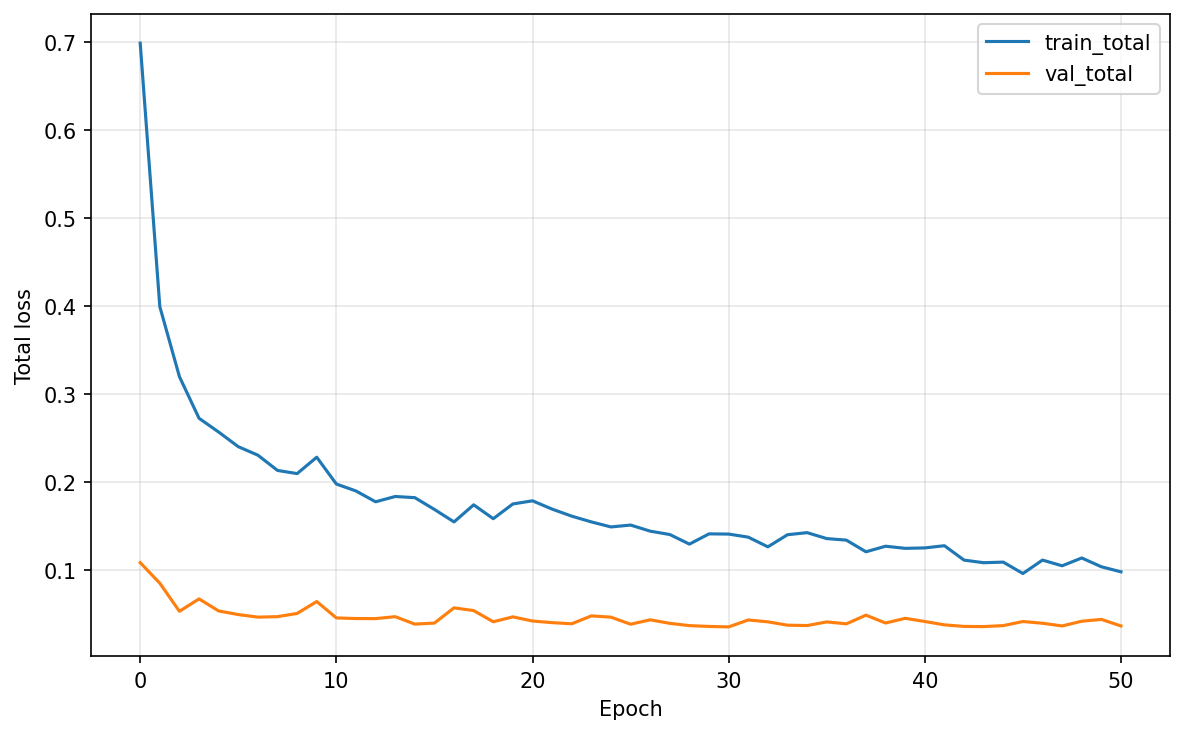

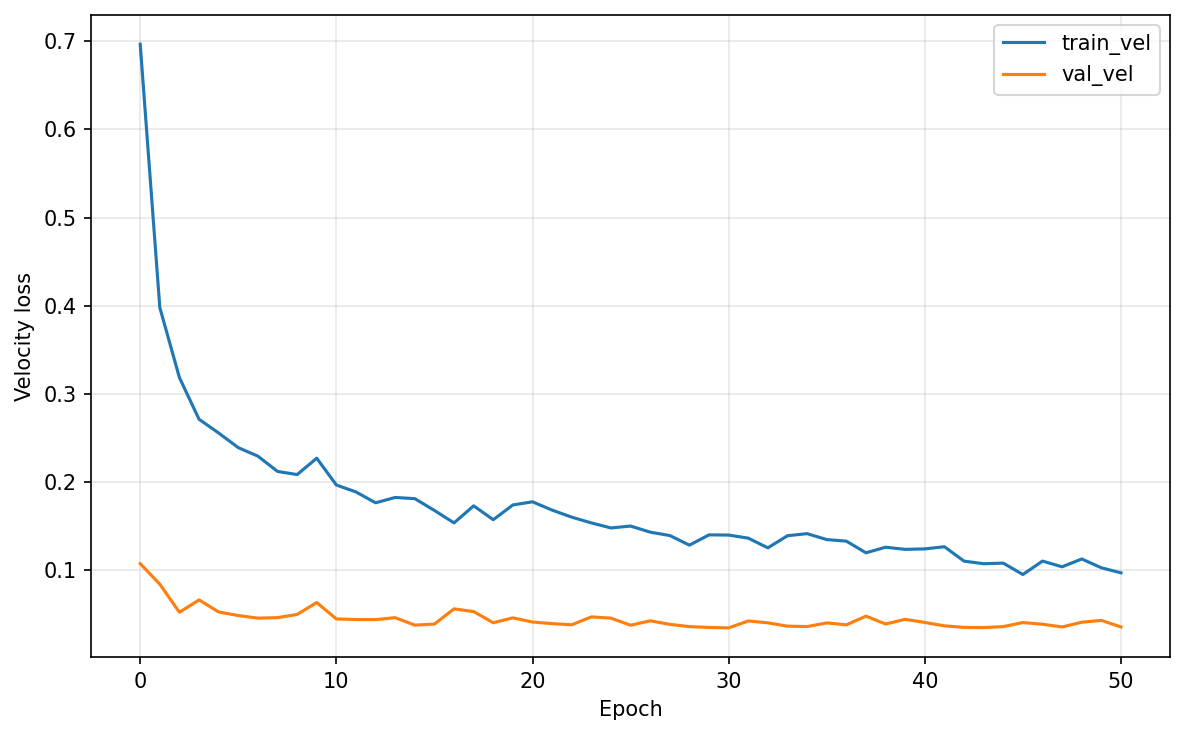

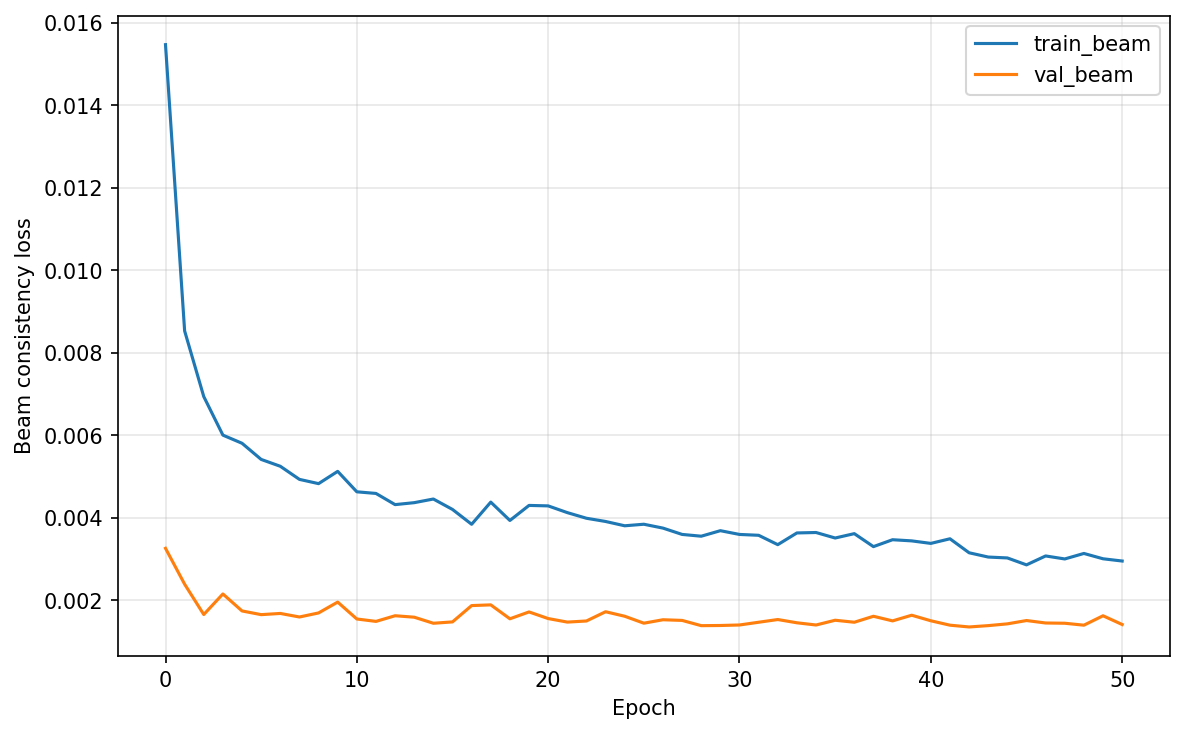

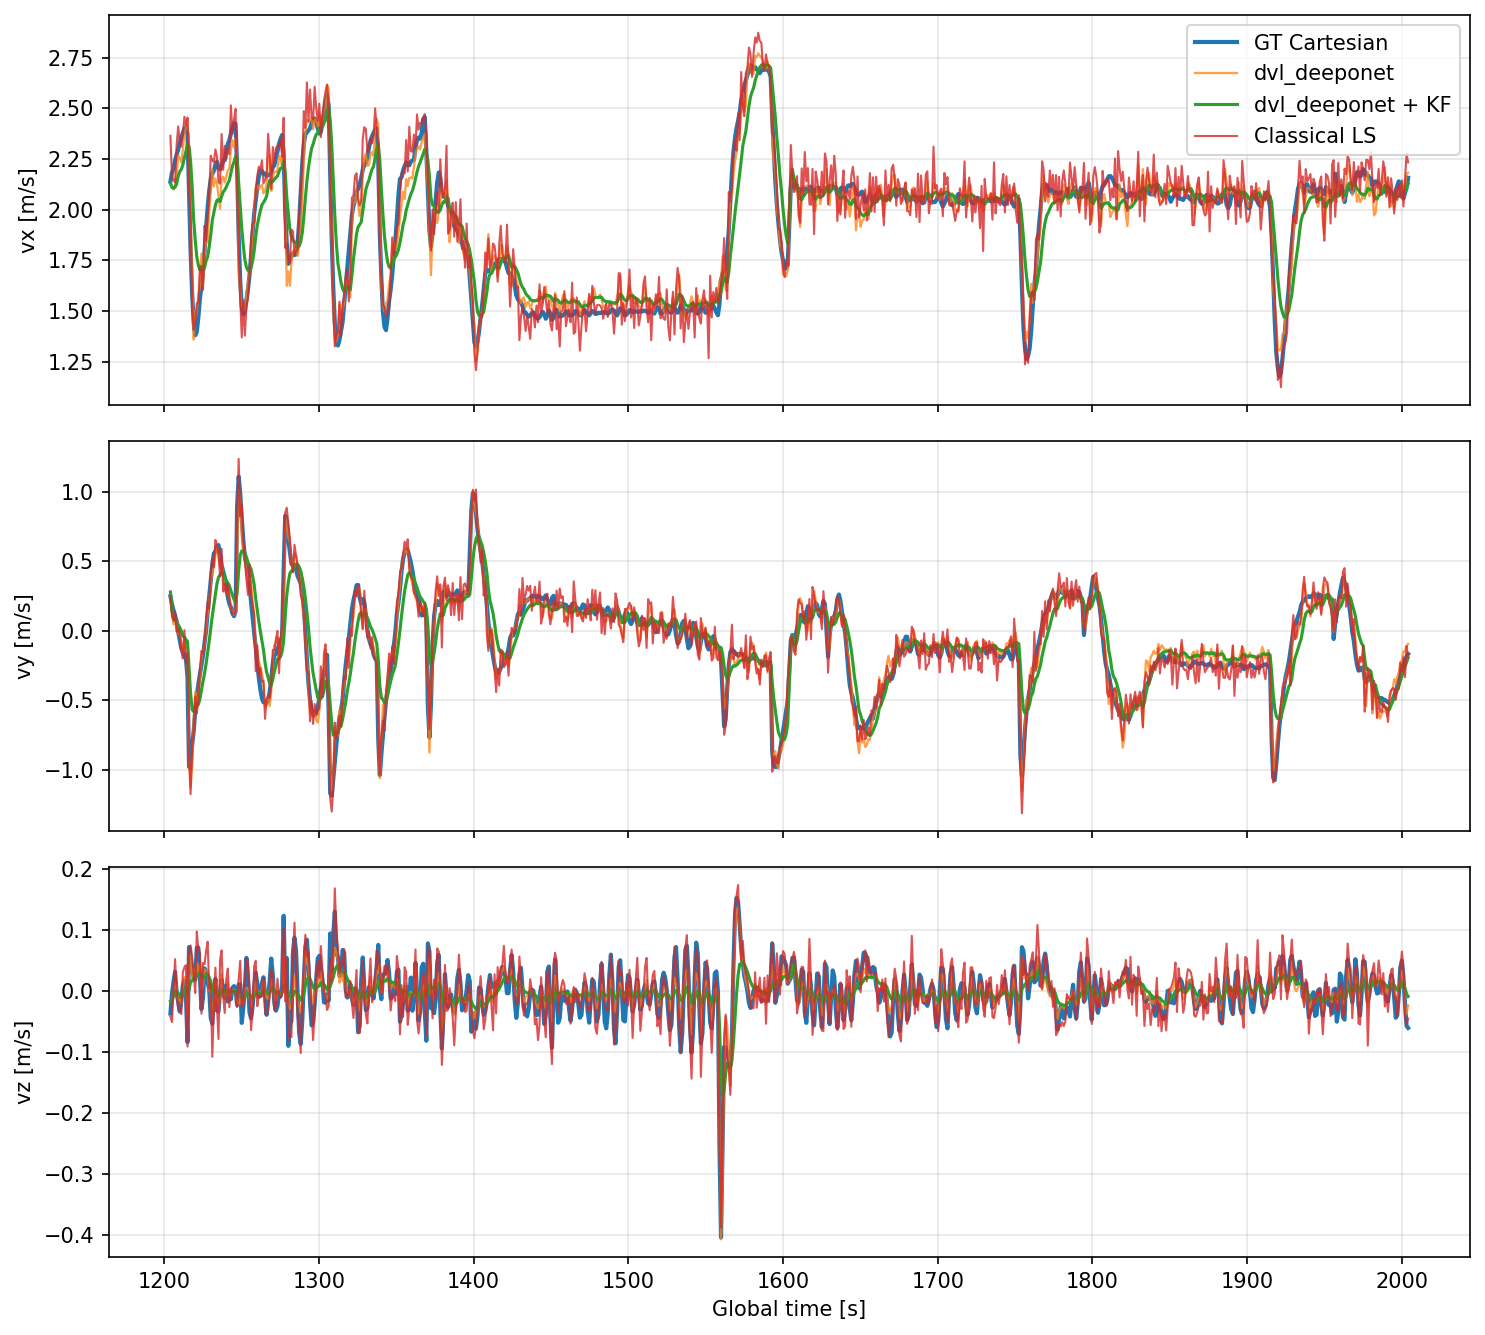

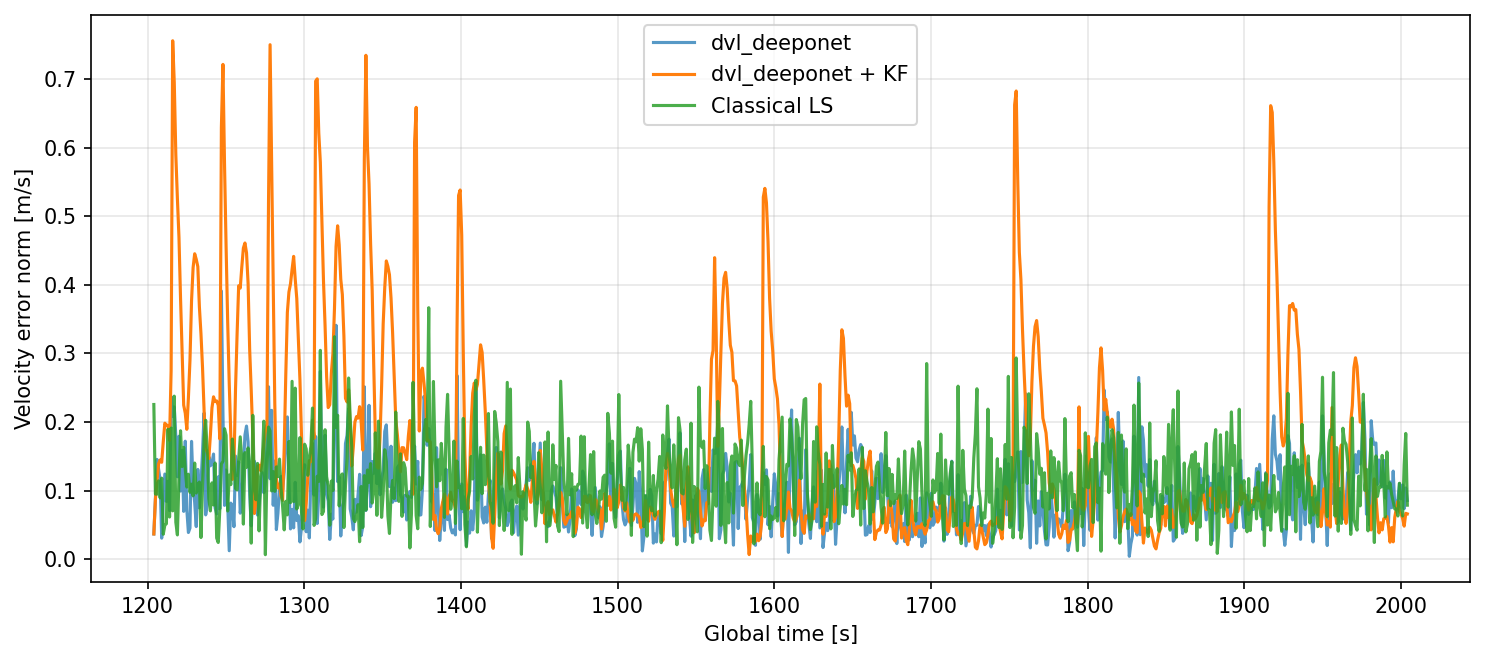

Figures saved in: /home/asahoo/DVL/dvl_deeponet_dvl_imu_velocity_results/figures


In [18]:
# ============================================================
# 16. Figures
# ============================================================

axis_names = ["vx", "vy", "vz"][:VEL_DIM]


def plot_loss(train_key, val_key, ylabel, filename):
    plt.figure(figsize=(8, 5), dpi=150)
    plt.plot(history[train_key], label=train_key)
    plt.plot(history[val_key], label=val_key)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_velocity_components(t_sec, gt, pred_nn, pred_kf, pred_ls, filename="velocity_components.png"):
    fig, axes = plt.subplots(VEL_DIM, 1, figsize=(10, 3 * VEL_DIM), dpi=150, sharex=True)
    if VEL_DIM == 1:
        axes = [axes]
    for d, ax in enumerate(axes):
        ax.plot(t_sec, gt[:, d], label="GT Cartesian", linewidth=2)
        ax.plot(t_sec, pred_nn[:, d], label="dvl_deeponet", linewidth=1.1, alpha=0.75)
        ax.plot(t_sec, pred_kf[:, d], label="dvl_deeponet + KF", linewidth=1.5)
        ax.plot(t_sec, pred_ls[:, d], label="Classical LS", linewidth=1.0, alpha=0.8)
        ax.set_ylabel(f"{axis_names[d]} [m/s]")
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Global time [s]")
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_velocity_error(t_sec, gt, pred_nn, pred_kf, pred_ls, filename="velocity_error_time.png"):
    err_nn = np.linalg.norm(pred_nn - gt, axis=1)
    err_kf = np.linalg.norm(pred_kf - gt, axis=1)
    err_ls = np.linalg.norm(pred_ls - gt, axis=1)
    plt.figure(figsize=(10, 4.5), dpi=150)
    plt.plot(t_sec, err_nn, label="dvl_deeponet", alpha=0.75)
    plt.plot(t_sec, err_kf, label="dvl_deeponet + KF", linewidth=1.5)
    plt.plot(t_sec, err_ls, label="Classical LS", alpha=0.85)
    plt.xlabel("Global time [s]")
    plt.ylabel("Velocity error norm [m/s]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_loss("train_total", "val_total", "Total loss", "loss_total.png")
plot_loss("train_vel", "val_vel", "Velocity loss", "loss_velocity.png")
plot_loss("train_beam", "val_beam", "Beam consistency loss", "loss_beam_consistency.png")

# Full plot can be long; the test split is usually the most useful view.
test_values = split_predictions["test"]
plot_velocity_components(
    test_values["time"], test_values["gt"], test_values["pred"], test_values["kf"], test_values["ls"],
    filename="velocity_components_test.png",
)
plot_velocity_error(
    test_values["time"], test_values["gt"], test_values["pred"], test_values["kf"], test_values["ls"],
    filename="velocity_error_time_test.png",
)

print("Figures saved in:", FIG_DIR.resolve())



## Notes

- IMU is loaded from `A-KIT/AUV_IMU_npy/IMU_trajectory*.npy` with format `[time, ax, ay, az, gx, gy, gz]`.
- The main dvl_deeponet uses IMU linearly avg to the 1 Hz DVL timestamps.
- This is **DVL+IMU as network input**, not a full inertial navigation filter.
- The velocity KF smooths only `[vx, vy, vz]`; it does not estimate position. Tune `KF_Q_VEL` and `KF_R_VEL` in the KF cell.
- If classical LS is already near-perfect, IMU may not improve much. IMU helps more when DVL beams are noisy, biased, dropped out, or dynamically corrupted.
- `ALPHA_DEG` must match the beam-generation angle in A-KIT. A wrong angle will make the LS baseline and beam-consistency loss misleading.
- The default split uses whole trajectories for train/validation/test. This is harder and more realistic than randomly splitting samples from every trajectory.


- For 3-fold trajectory cross-validation, set `CV_FOLD = 0`, `1`, or `2` in the split cell and rerun the notebook.

- Missing-beam robustness is tested only on the test trajectories: trajectory 12 uses one missing beam and trajectory 13 uses two missing beams every 2 seconds.

- TC/ELC velocity-only baselines compute a simple raw-IMU INS velocity and attitude from `A-KIT/AUV_IMU_npy`; LC is skipped for two-missing-beam cases because fewer than 3 beams are available.

- The optional multi-branch dvl_deeponet uses one branch for full beams and separate branch sub-networks for selected missing-beam patterns; all other losses and evaluation steps remain unchanged.
